In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import os


import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

from sklearn.preprocessing import LabelEncoder

import gc
from sklearn.model_selection import KFold, StratifiedKFold
from sklearn.metrics import roc_curve, roc_auc_score
from lightgbm import LGBMClassifier, log_evaluation, early_stopping
import time

In [10]:
for dirname, _, filenames in os.walk(r"C:\Users\ASus\OneDrive\Desktop\jbooks\Home Credit Default Risk\home-credit-default-risk"):
    for filename in filenames:
        print(os.path.join(dirname, filename))

C:\Users\ASus\OneDrive\Desktop\jbooks\Home Credit Default Risk\home-credit-default-risk\application_test.csv
C:\Users\ASus\OneDrive\Desktop\jbooks\Home Credit Default Risk\home-credit-default-risk\application_train.csv
C:\Users\ASus\OneDrive\Desktop\jbooks\Home Credit Default Risk\home-credit-default-risk\bureau.csv
C:\Users\ASus\OneDrive\Desktop\jbooks\Home Credit Default Risk\home-credit-default-risk\bureau_balance.csv
C:\Users\ASus\OneDrive\Desktop\jbooks\Home Credit Default Risk\home-credit-default-risk\credit_card_balance.csv
C:\Users\ASus\OneDrive\Desktop\jbooks\Home Credit Default Risk\home-credit-default-risk\HomeCredit_columns_description.csv
C:\Users\ASus\OneDrive\Desktop\jbooks\Home Credit Default Risk\home-credit-default-risk\installments_payments.csv
C:\Users\ASus\OneDrive\Desktop\jbooks\Home Credit Default Risk\home-credit-default-risk\POS_CASH_balance.csv
C:\Users\ASus\OneDrive\Desktop\jbooks\Home Credit Default Risk\home-credit-default-risk\previous_application.csv
C:\U

In [11]:
data_path = r"C:\Users\ASus\OneDrive\Desktop\jbooks\Home Credit Default Risk\home-credit-default-risk"

In [12]:
app_train = pd.read_csv(f'{data_path}/application_train.csv')
app_test=pd.read_csv(f'{data_path}/application_test.csv')
bureau = pd.read_csv(f'{data_path}/bureau.csv')
bureau_balance = pd.read_csv(f'{data_path}/bureau_balance.csv')
pos_cash_balance = pd.read_csv(f'{data_path}/POS_CASH_balance.csv')
credit_card_balance = pd.read_csv(f'{data_path}/credit_card_balance.csv')
previous_application = pd.read_csv(f'{data_path}/previous_application.csv')
installments_payments = pd.read_csv(f'{data_path}/installments_payments.csv')

In [13]:
import os
print(os.path.exists(data_path))

True


In [14]:
print(os.listdir(data_path))

['application_test.csv', 'application_train.csv', 'bureau.csv', 'bureau_balance.csv', 'credit_card_balance.csv', 'HomeCredit_columns_description.csv', 'installments_payments.csv', 'POS_CASH_balance.csv', 'previous_application.csv', 'sample_submission.csv']


In [15]:
print(app_train.shape)
print(app_test.shape)

(307511, 122)
(48744, 121)


Data First look, and Merging Tables

In [16]:
bb_agg = (bureau_balance.groupby("SK_ID_BUREAU").agg(months_min=("MONTHS_BALANCE", "min"),months_max=("MONTHS_BALANCE", "max"),status_last=("STATUS", "last")).reset_index())

In [17]:
bureau = bureau.merge(bb_agg, on="SK_ID_BUREAU", how="left")

In [18]:
# Aggregate the bureau table with app_train by customer (SK_ID_CURR)
bureau_agg = bureau.groupby('SK_ID_CURR').agg({
    'AMT_CREDIT_SUM': ['mean', 'sum'],
    'AMT_CREDIT_SUM_OVERDUE': ['mean', 'sum'],
    'AMT_CREDIT_SUM_DEBT': ['mean', 'sum'],
    "CREDIT_ACTIVE": lambda s: (s == "Active").sum(),
    "CREDIT_DAY_OVERDUE": ["max"],
    'AMT_ANNUITY': ['mean', 'sum'],
    'DAYS_CREDIT': ['mean', 'min', 'max'],
    'CREDIT_TYPE': 'nunique'  
}).reset_index()

In [19]:
# Flatten MultiIndex columns
bureau_agg.columns = ['_'.join(col).strip() for col in bureau_agg.columns.values]
bureau_agg.rename(columns={'SK_ID_CURR_': 'SK_ID_CURR'}, inplace=True)

In [20]:
app_train = pd.merge(app_train, bureau_agg, on='SK_ID_CURR', how='left')
app_test = pd.merge(app_test, bureau_agg, on='SK_ID_CURR', how='left')

In [21]:
PA_agg = previous_application.groupby("SK_ID_CURR").agg({
    "SK_ID_PREV": "count",  # Count of previous applications (how many loans each customer has applied for)
    "NAME_CONTRACT_STATUS": lambda s: (s == "Approved").sum(),  # Count of approved applications
    "AMT_APPLICATION": "mean",  # Mean application amount
    "AMT_CREDIT": "mean",  # Mean credit amount
}).reset_index()
#--

In [22]:
app_train = pd.merge(app_train, PA_agg, on='SK_ID_CURR', how='left')
app_test = pd.merge(app_test, PA_agg, on='SK_ID_CURR', how='left')

In [23]:
# Positive = paid late (bad)
# Negative = paid early (good)

installments_payments["PAY_DIFF"] = installments_payments["AMT_PAYMENT"] - installments_payments["AMT_INSTALMENT"]
installments_payments["PAY_DELAY_DAYS"] = installments_payments["DAYS_ENTRY_PAYMENT"] - installments_payments["DAYS_INSTALMENT"]

In [24]:
IP_agg = (
    installments_payments
    .groupby("SK_ID_CURR")
    .agg(
        INST_CNT=("SK_ID_PREV", "count"),
        INST_PAY_DIFF_MEAN=("PAY_DIFF", "mean"),
        INST_PAY_DIFF_MIN=("PAY_DIFF", "min"),
        INST_PAY_DIFF_MAX=("PAY_DIFF", "max"),
        INST_DELAY_MEAN=("PAY_DELAY_DAYS", "mean"),
        INST_DELAY_MAX=("PAY_DELAY_DAYS", "max"),
        INST_TOTAL_PAID=("AMT_PAYMENT", "sum"),
        INST_TOTAL_DUE=("AMT_INSTALMENT", "sum"),
    )
).reset_index()

In [25]:
app_train = pd.merge(app_train, IP_agg, on='SK_ID_CURR', how='left')
app_test = pd.merge(app_test, IP_agg, on='SK_ID_CURR', how='left')

In [26]:
pos_agg = pos_cash_balance.groupby("SK_ID_CURR").agg({
    "SK_ID_PREV": "nunique",  # Count unique POS loans per customer
    "SK_DPD": "max"  # Max of SK_DPD (maximum delinquency)
}).reset_index()
#--

In [27]:
app_train = pd.merge(app_train, pos_agg, on='SK_ID_CURR', how='left')
app_test = pd.merge(app_test, pos_agg, on='SK_ID_CURR', how='left')

In [28]:
cc_agg = credit_card_balance.groupby("SK_ID_CURR").agg({
    "AMT_BALANCE": "mean",  # Mean balance on credit card
    "SK_DPD": "mean"  # Mean delinquency period on credit card
}).reset_index()

#--

In [29]:
app_train = pd.merge(app_train, cc_agg, on='SK_ID_CURR', how='left')
app_test = pd.merge(app_test, cc_agg, on='SK_ID_CURR', how='left')

In [31]:
print(f'The applicatoin training dataset contains {app_train.shape[1]} columns and {app_train.shape[0]} raws')
print(f'The applicatoin test dataset contains {app_test.shape[1]} columns and {app_test.shape[0]} raws')

The applicatoin training dataset contains 152 columns and 307511 raws
The applicatoin test dataset contains 151 columns and 48744 raws


In [32]:
print(app_train.columns)

Index(['SK_ID_CURR', 'TARGET', 'NAME_CONTRACT_TYPE', 'CODE_GENDER',
       'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL',
       'AMT_CREDIT_x', 'AMT_ANNUITY',
       ...
       'INST_PAY_DIFF_MIN', 'INST_PAY_DIFF_MAX', 'INST_DELAY_MEAN',
       'INST_DELAY_MAX', 'INST_TOTAL_PAID', 'INST_TOTAL_DUE', 'SK_ID_PREV_y',
       'SK_DPD_x', 'AMT_BALANCE', 'SK_DPD_y'],
      dtype='object', length=152)


In [33]:
print(app_train.shape)
print(app_test.shape)

(307511, 152)
(48744, 151)


In [35]:
df_train_categorical=app_train.select_dtypes(include='object')
df_train_numerical=app_train.select_dtypes(exclude='object')

df_test_categorical=app_test.select_dtypes(include='object')
df_test_numerical=app_test.select_dtypes(exclude='object')

EDA
Categorical Features

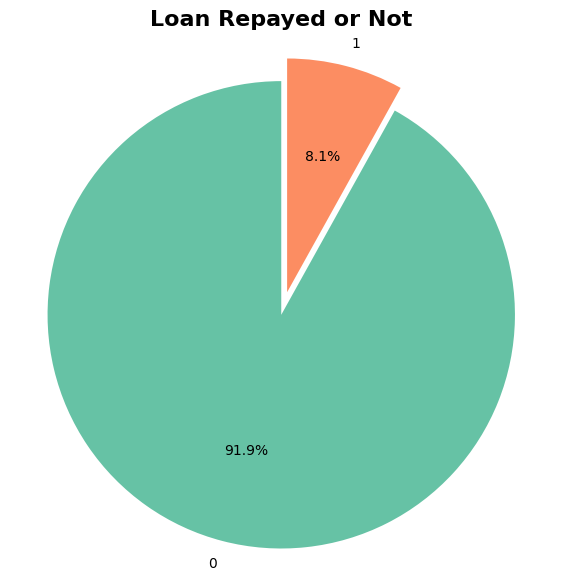

In [36]:
temp = app_train["TARGET"].value_counts()
df = pd.DataFrame({'labels': temp.index, 'values': temp.values})

colors = sns.color_palette("Set2", n_colors=len(df))

plt.figure(figsize=(7, 7))
plt.pie(df['values'], labels=df['labels'], autopct='%1.1f%%', startangle=90, colors=colors, explode=(0.1, 0))

plt.title('Loan Repayed or Not', fontsize=16, weight='bold')

plt.axis('equal')  
plt.show()


Data is highly inbalance

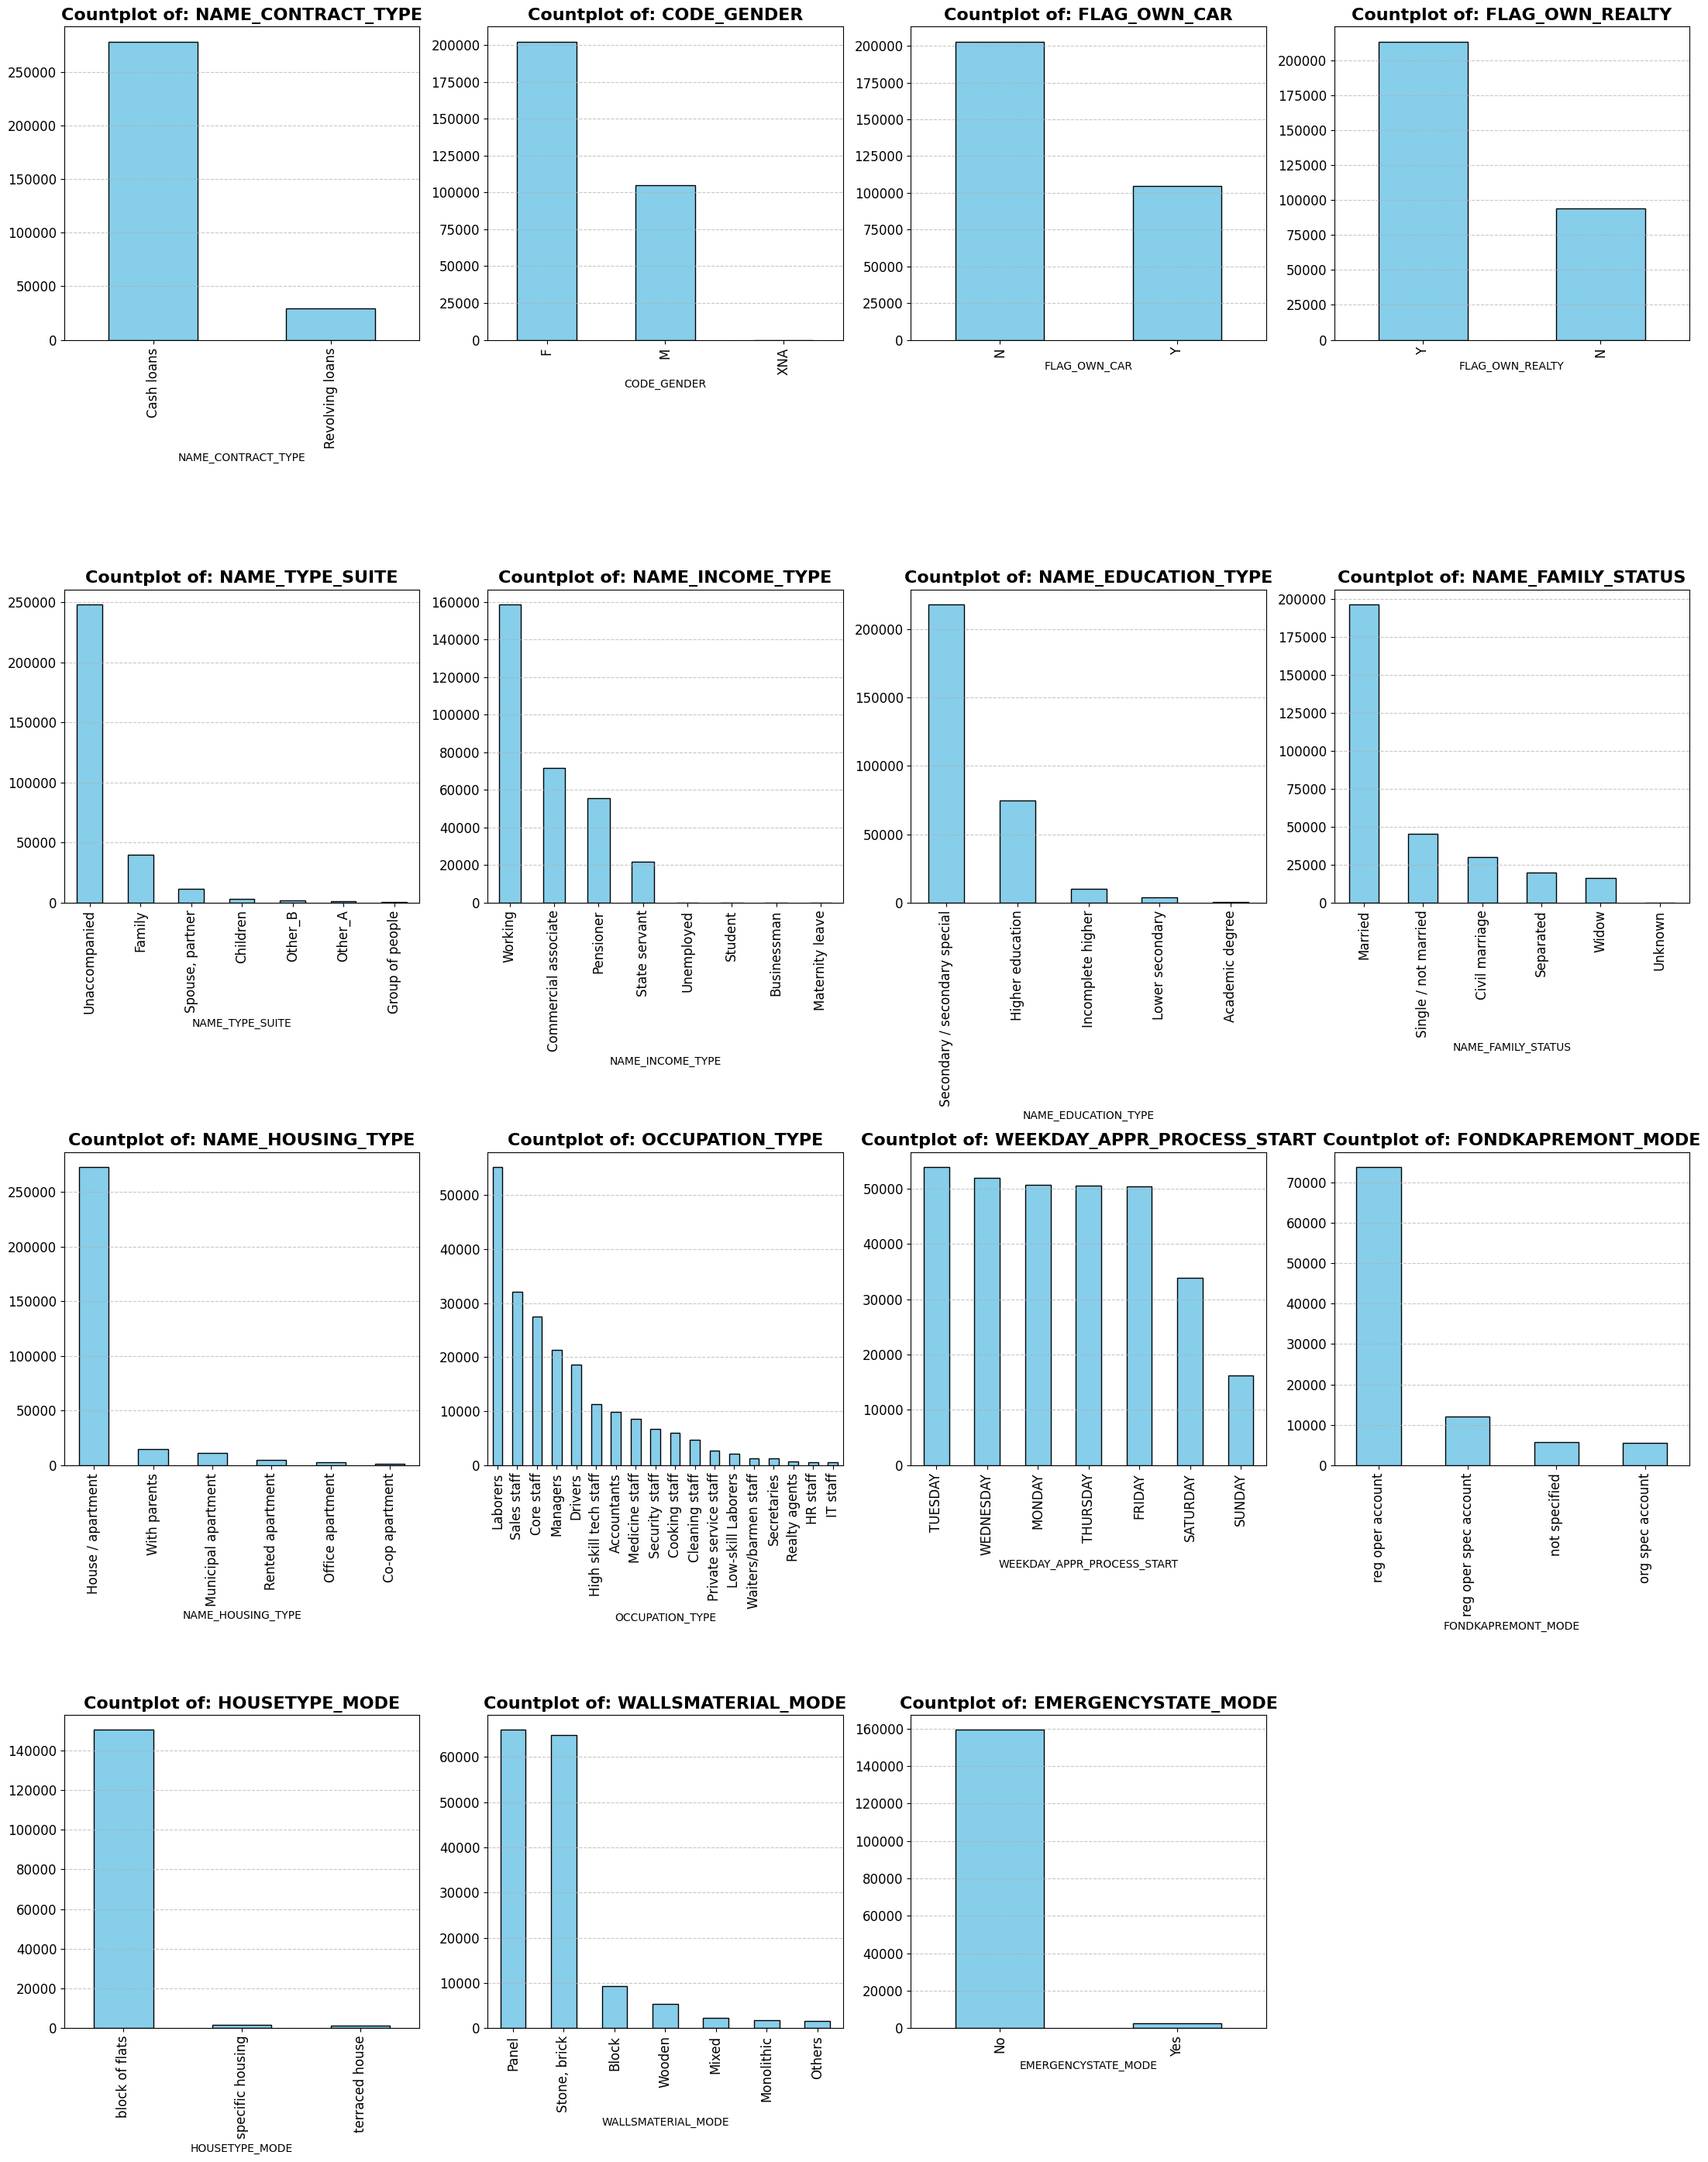

In [37]:
plt.figure(figsize=(22, 28))
for i, col in enumerate(df_train_categorical.drop(columns=['ORGANIZATION_TYPE'])):
    
    plt.subplot(4, 4, i + 1)
    df_train_categorical[col].value_counts().plot(kind='bar', color='skyblue', edgecolor='black')
    
    plt.title(f'Countplot of: {col}', fontsize=16, fontweight='bold')
    plt.xticks( fontsize=12)
    plt.yticks(fontsize=12)
    plt.grid(True, axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

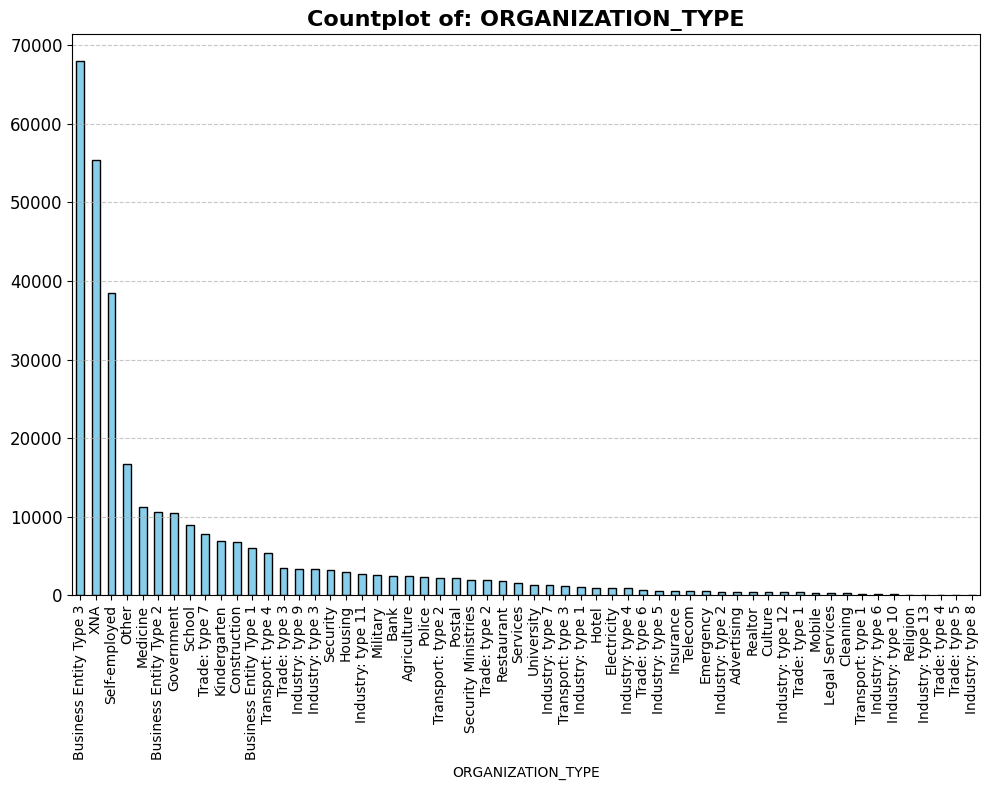

In [38]:
plt.figure(figsize=(10, 8))

df_train_categorical['ORGANIZATION_TYPE'].value_counts().plot(kind='bar', color='skyblue', edgecolor='black')

plt.title('Countplot of: ORGANIZATION_TYPE', fontsize=16, fontweight='bold')
plt.xticks(fontsize=10)
plt.yticks(fontsize=12)
plt.grid(True, axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


In [39]:
def plot_loan_percentage(feature, df=app_train, colormap='cividis', rotation=0, figsize=(8, 6)):

    # Calculate the percentage of Target based on the given feature values
    loan_percentage = df.groupby([feature, 'TARGET']).size().unstack(fill_value=0)

    # Convert counts to percentages based on the given feature values
    loan_percentage = loan_percentage.div(loan_percentage.sum(axis=1), axis=0) * 100

    # Sort the values in ascending order based on Target percentage (ascending order for 'Loan_Statused')
    loan_percentage = loan_percentage[['Repaid', 'Not Repaid']].sort_values(by='Repaid', ascending= False)

    # Plot stacked bar chart for percentage comparison
    ax = loan_percentage.plot(kind='bar', stacked=True, figsize=figsize, colormap=colormap)

    # Add percentage labels on top of the bars
    for p in ax.patches:
        height = p.get_height()
        if height > 0:  # only label bars with non-zero height
            ax.text(p.get_x() + p.get_width() / 2, p.get_height() + p.get_y(),
                    f'{height:.1f}%', ha='center', va='bottom', fontsize=12, color='black')

    for label in ax.get_xticklabels():
        label.set_horizontalalignment('right')

    plt.title(f'Percentage of Loan_Status for {feature.capitalize()}', fontsize=14)
    plt.xlabel(feature.capitalize(), fontsize=12)
    plt.ylabel('Percentage', fontsize=12)
    plt.xticks(rotation=rotation,fontsize=14)
    plt.legend(title='Loan_Status', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
    plt.tight_layout()

    plt.show()

In [40]:
app_train['TARGET']=app_train['TARGET'].map({0: 'Repaid', 1: 'Not Repaid'})

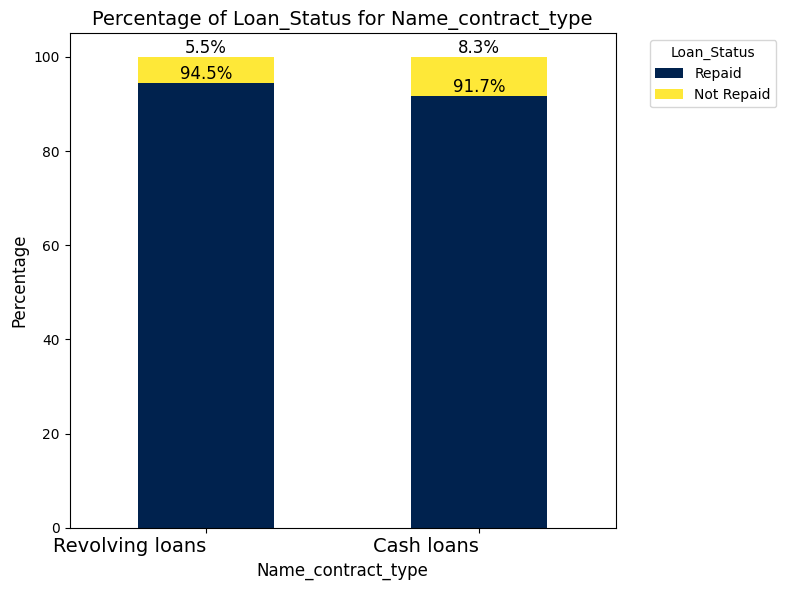

In [41]:
plot_loan_percentage('NAME_CONTRACT_TYPE')

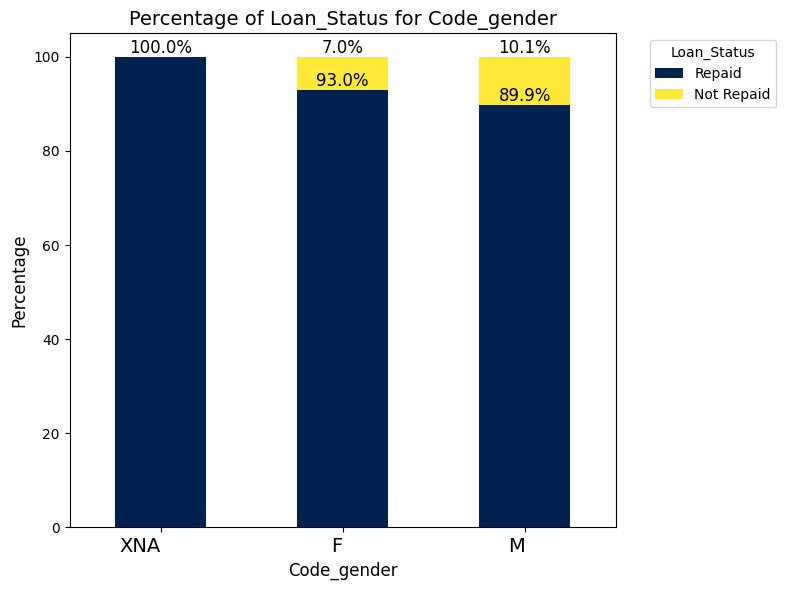

In [42]:
plot_loan_percentage('CODE_GENDER')

irrelevant value XNA, will be handled during cleaning

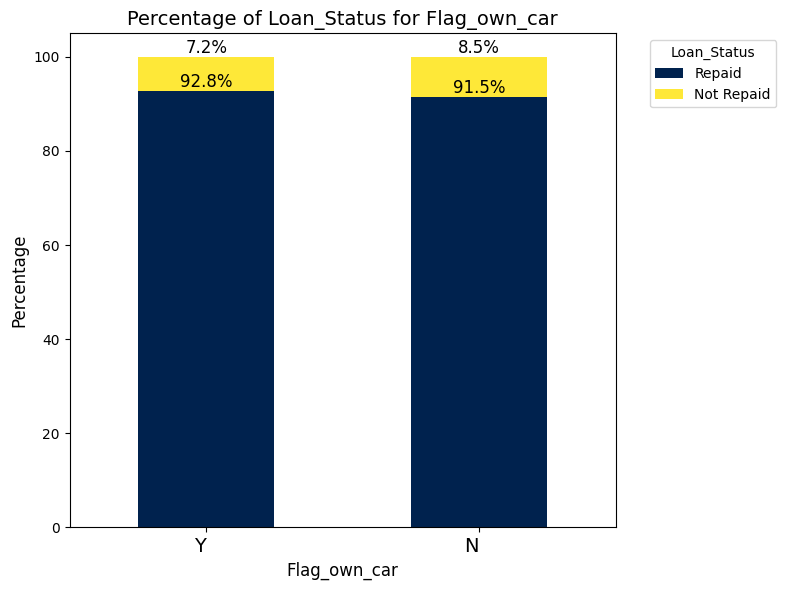

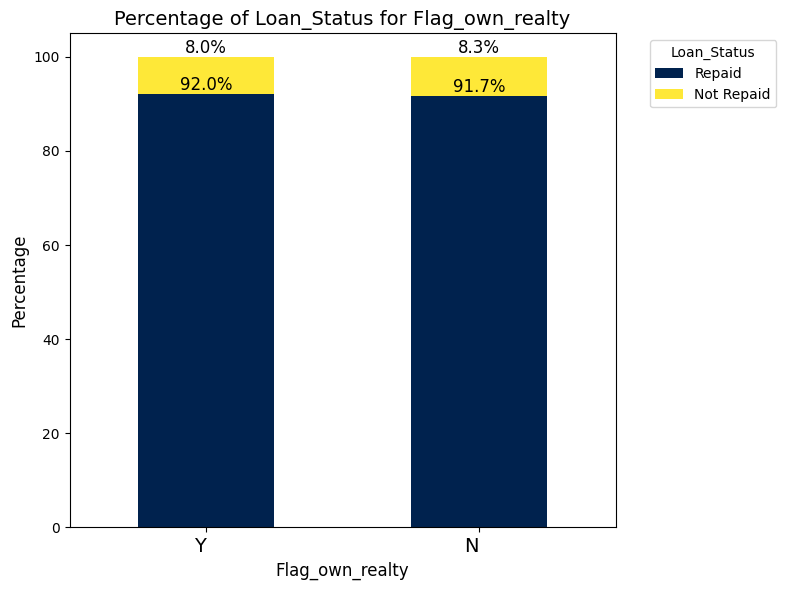

(None, None)

In [43]:
# purpose of the loan
plot_loan_percentage('FLAG_OWN_CAR'),plot_loan_percentage('FLAG_OWN_REALTY')

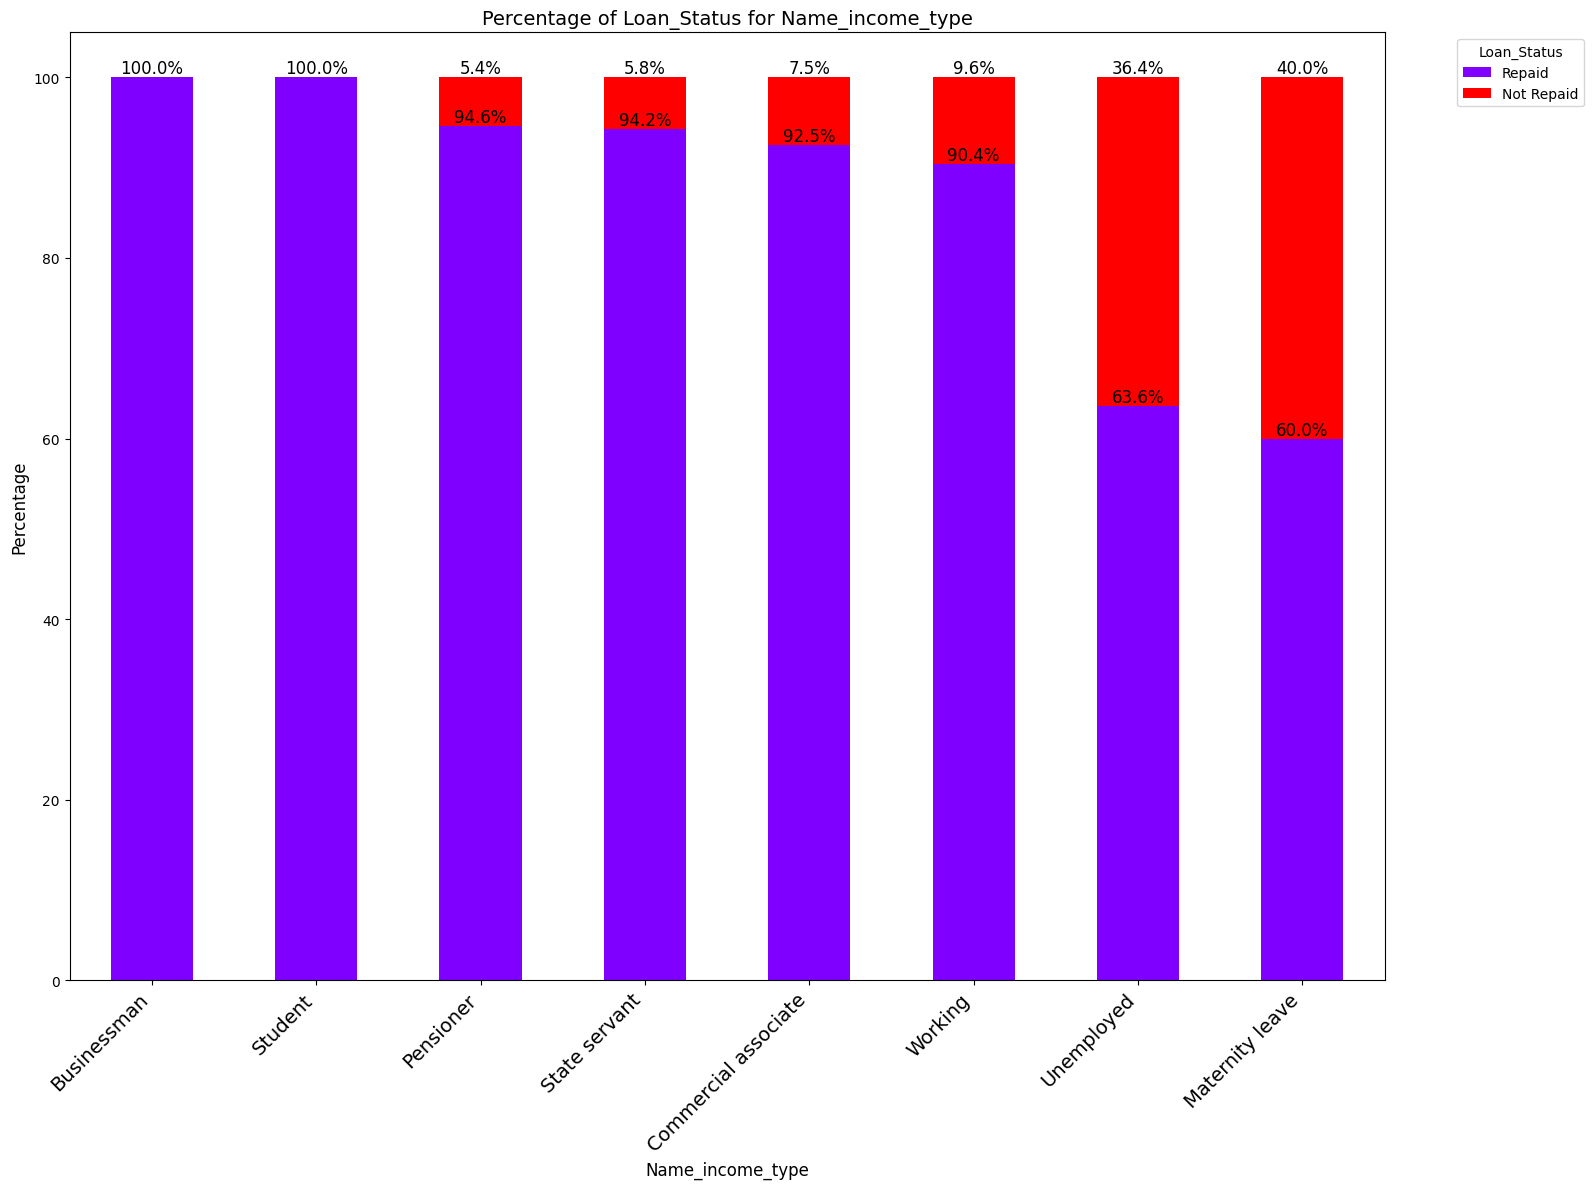

In [44]:
plot_loan_percentage('NAME_INCOME_TYPE', colormap='rainbow', rotation=45, figsize=(16,12))

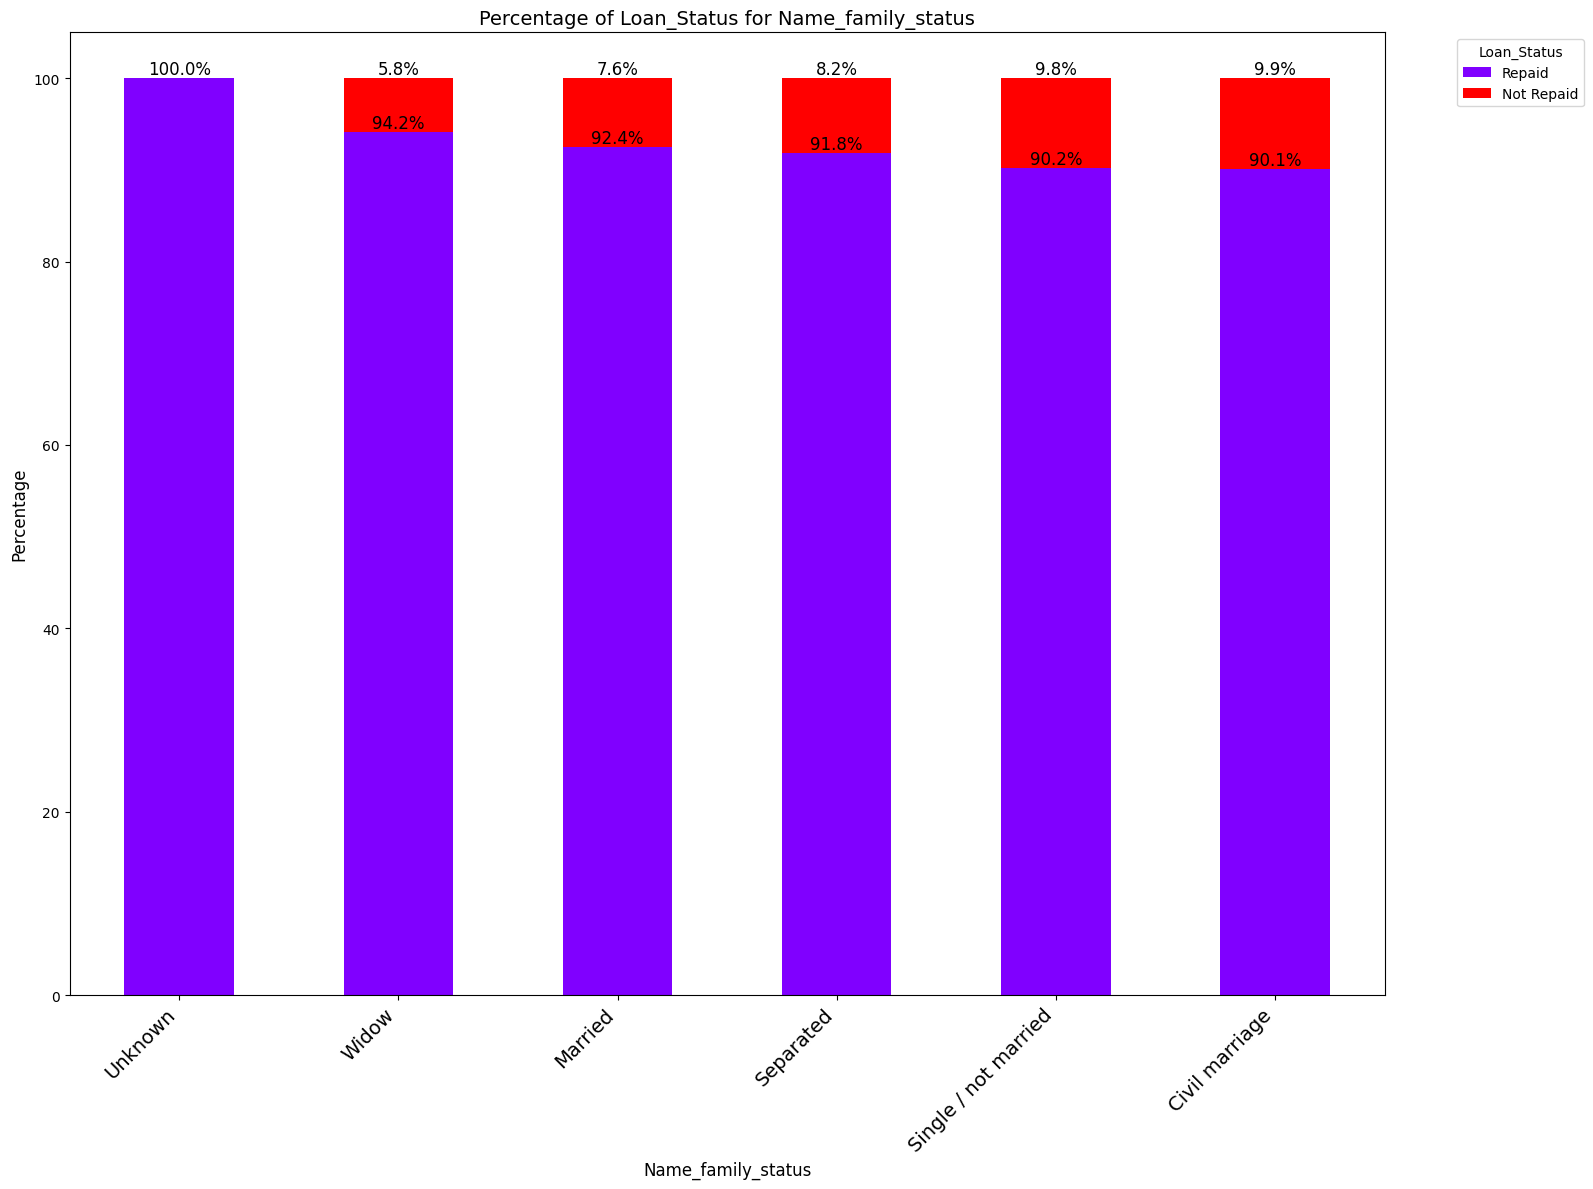

In [45]:
plot_loan_percentage('NAME_FAMILY_STATUS', colormap='rainbow', rotation=45, figsize=(16,12))

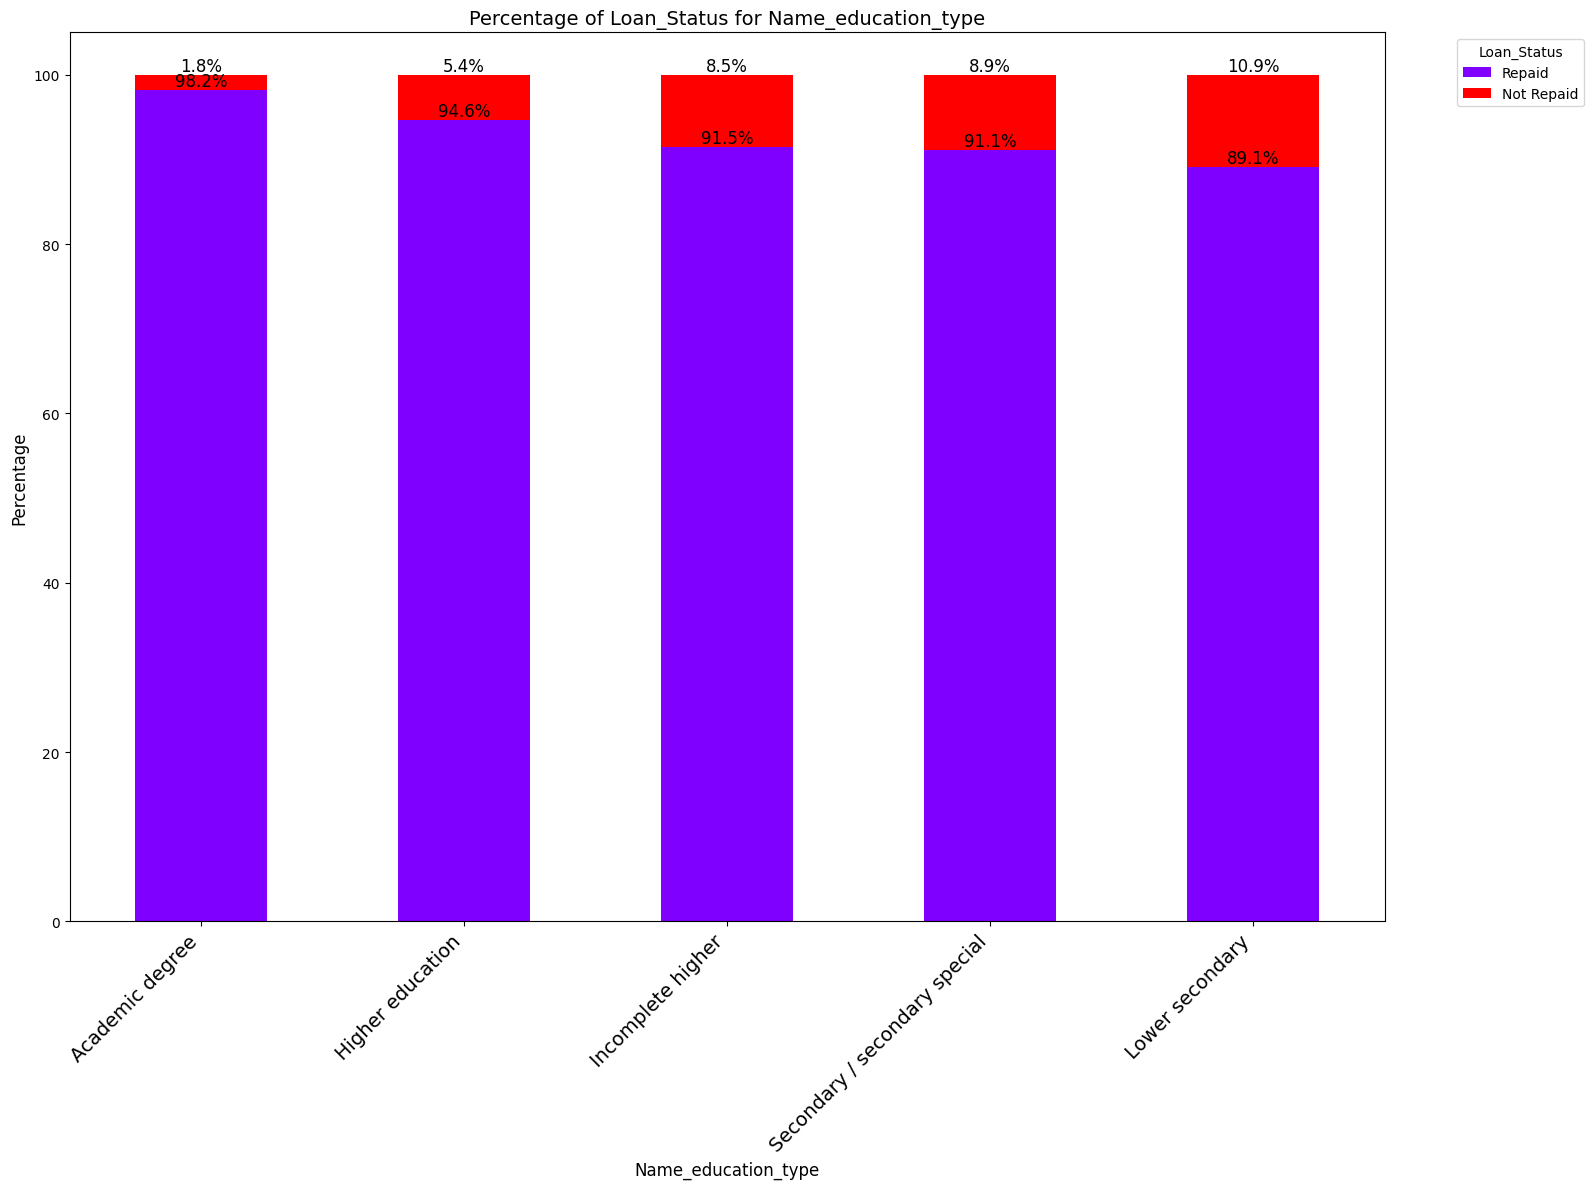

In [46]:
plot_loan_percentage('NAME_EDUCATION_TYPE', colormap='rainbow', rotation=45, figsize=(16,12))

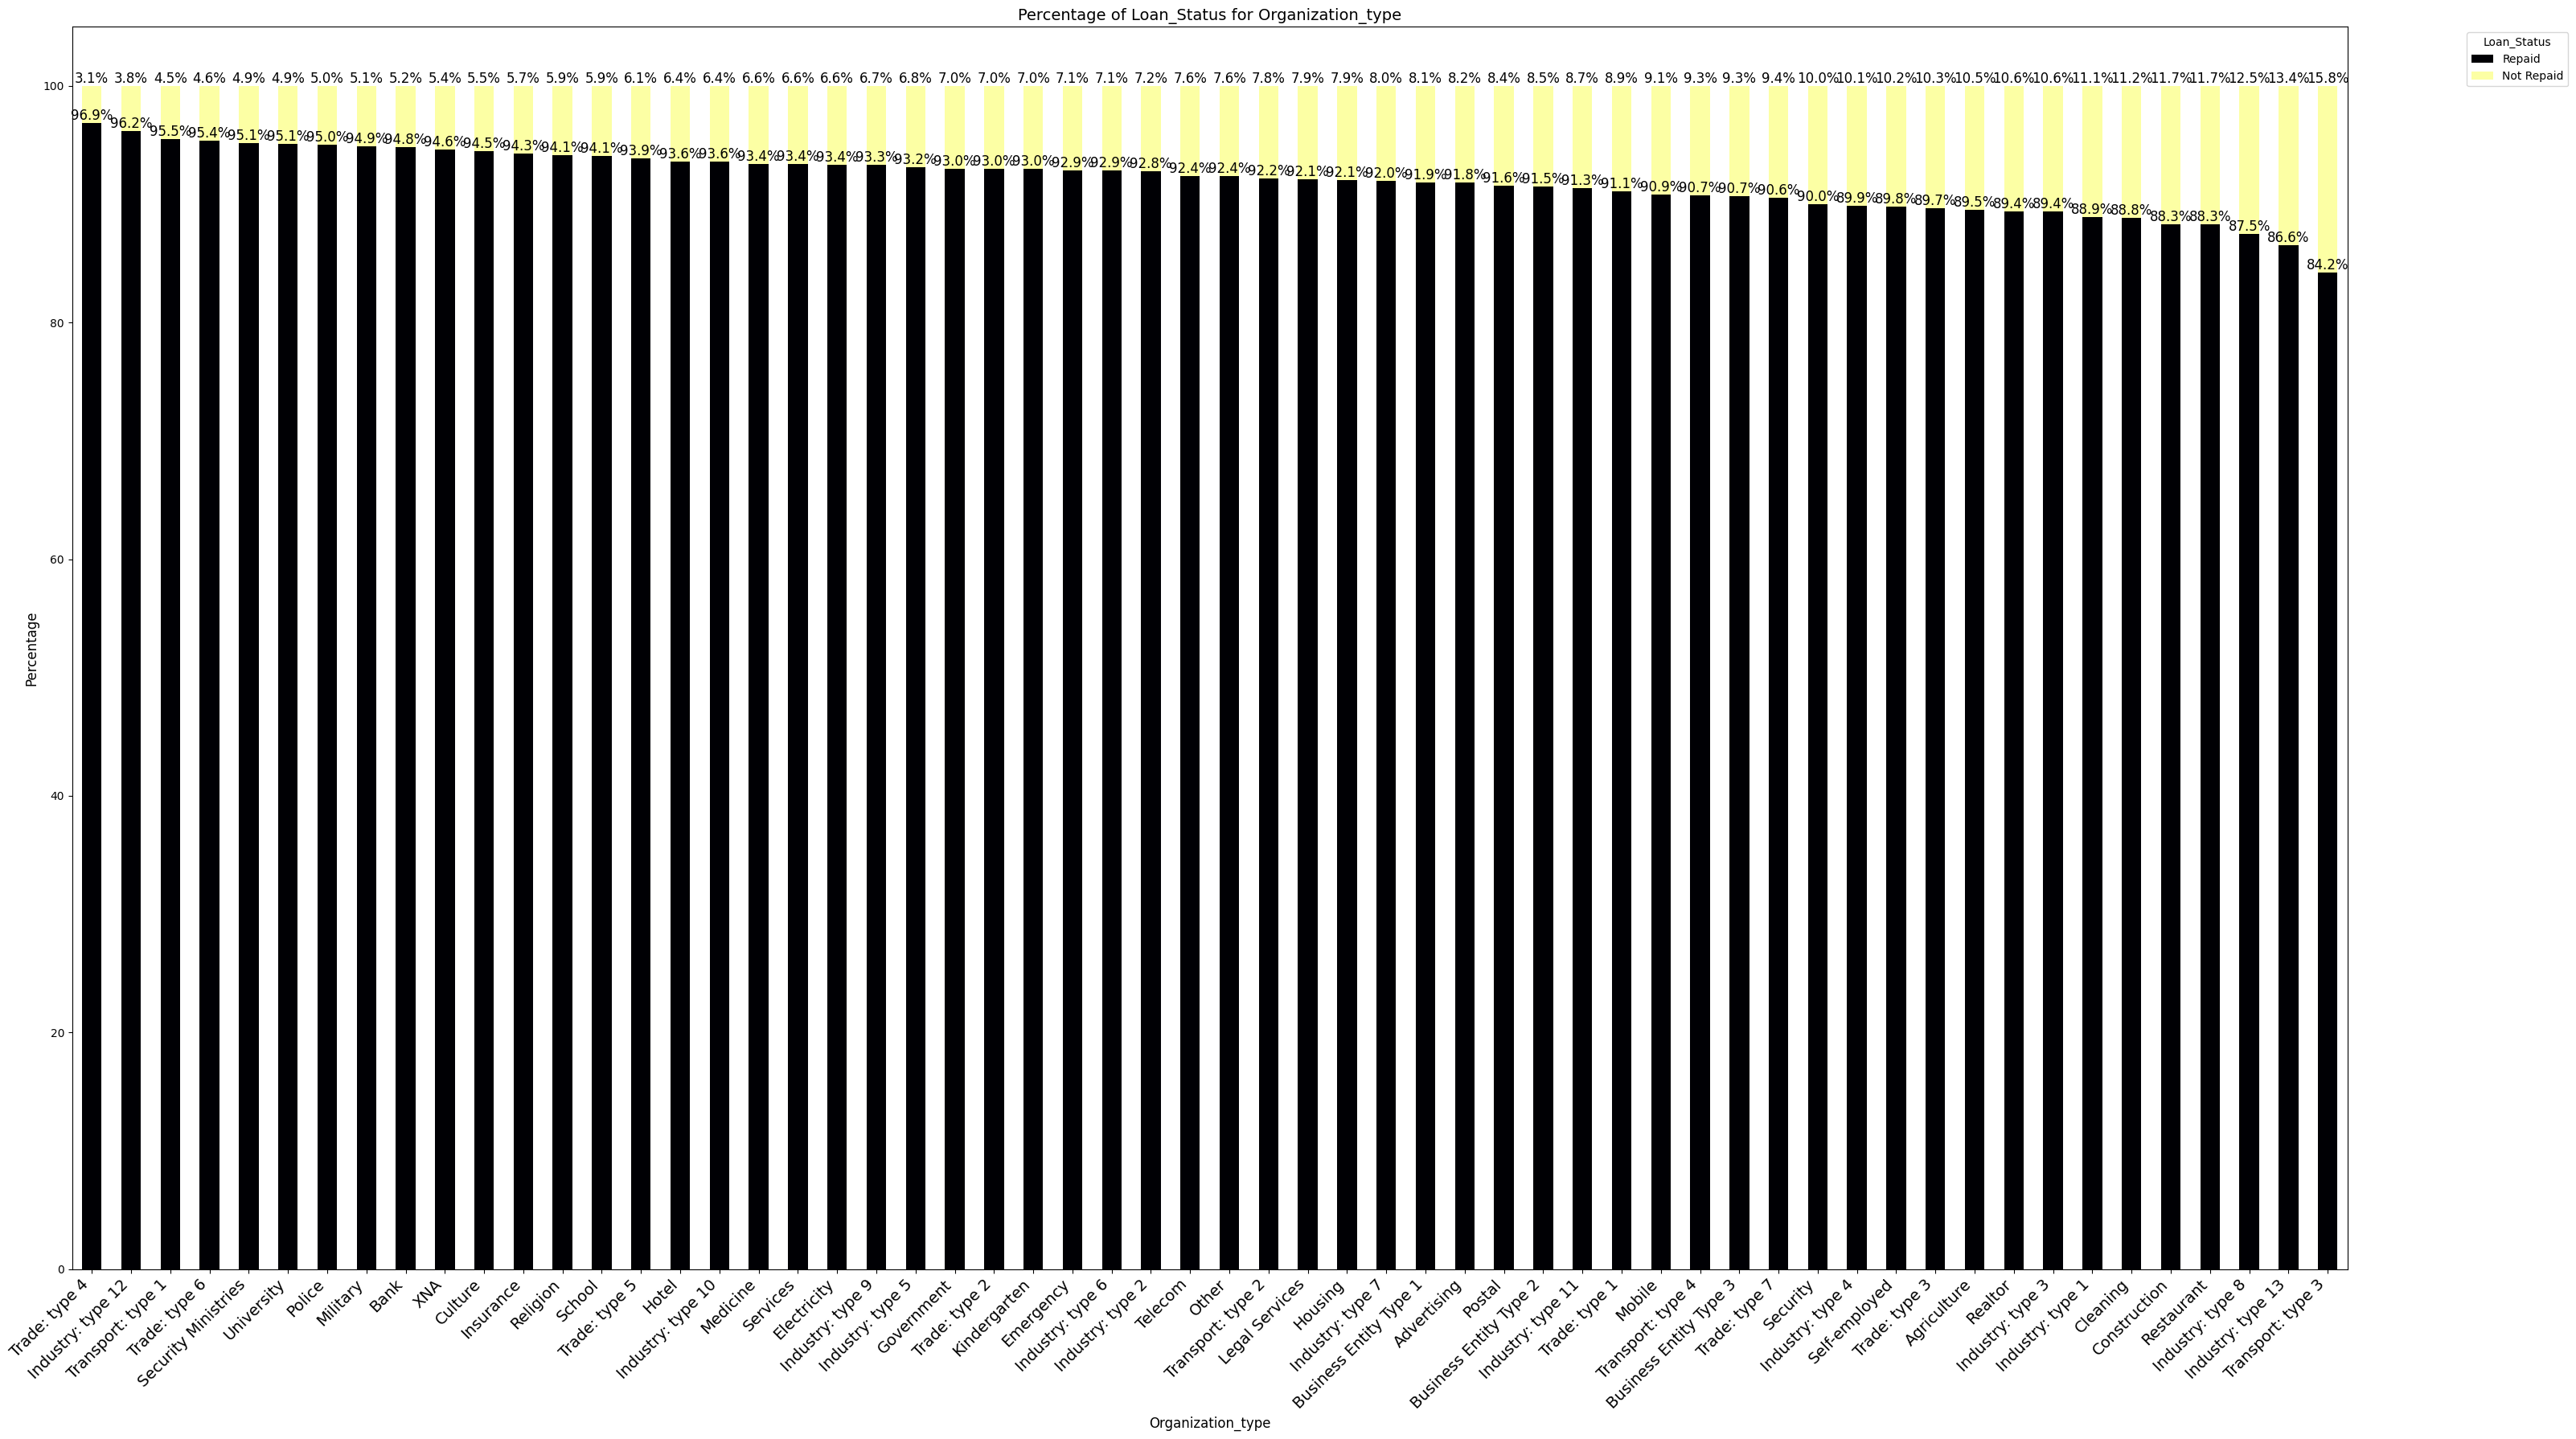

In [47]:
plot_loan_percentage('ORGANIZATION_TYPE',colormap='inferno',rotation=45, figsize=(32,18))

Continous Features

In [49]:
# Plot distribution of one feature
def plot_distribution(feature, color):
    plt.figure(figsize=(10, 6))
    plt.title(f"Distribution of {feature}", fontsize=16, fontweight='bold')
    sns.histplot(app_train[feature].dropna(), color=color, kde=True, bins=100, edgecolor='black')
    plt.xlabel(feature, fontsize=14)
    plt.ylabel('Density', fontsize=14)
    plt.tick_params(axis='both', which='major', labelsize=12)
    plt.grid(True, axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

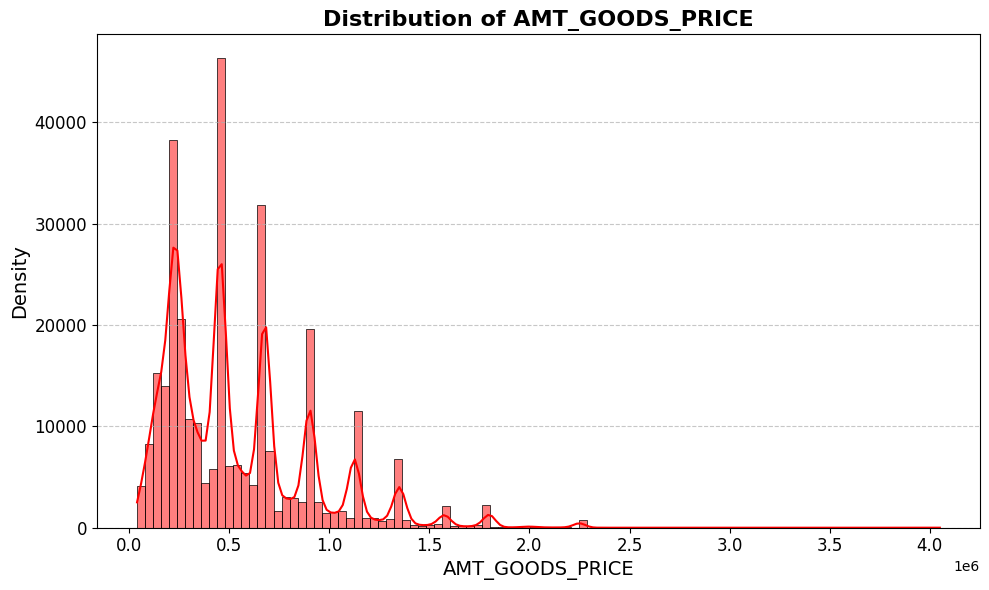

In [50]:
plot_distribution('AMT_GOODS_PRICE',color='red')

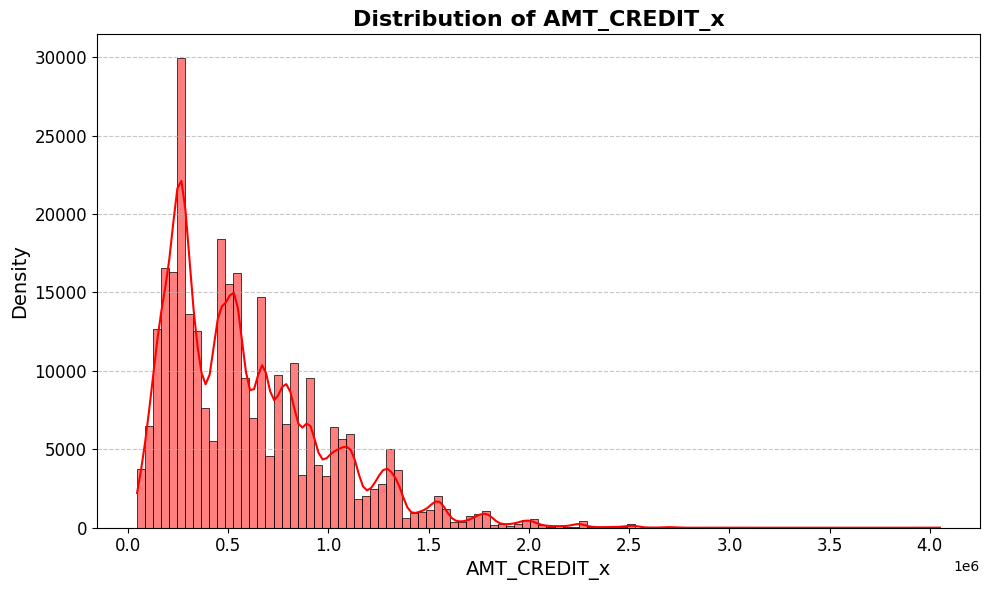

In [51]:
plot_distribution('AMT_CREDIT_x',color='red')

In [55]:
app_train['TARGET']=app_train['TARGET'].map({'Repaid': 0 , 'Not Repaid':1 })

In [56]:
def plot_distribution_continous(df, var):
    nrow = len(var)
    t1 = df.loc[df['TARGET'] != 0]
    t0 = df.loc[df['TARGET'] == 0]

    sns.set_style('whitegrid')
    plt.figure(figsize=(18, 14 * nrow))

    for i, feature in enumerate(var, 1):
        # Distribution plot
        plt.subplot(nrow, 2, i)
        plt.title(f"Distribution of {feature}", fontsize=16, fontweight='bold')
        sns.histplot(df[feature].dropna(), kde=True, bins=100, edgecolor='black', color='skyblue')
        plt.xlabel(feature, fontsize=14)
        plt.ylabel('Density', fontsize=14)
        plt.tick_params(axis='both', which='major', labelsize=12)
        plt.grid(True, axis='y', linestyle='--', alpha=0.7)

        # Density plot by TARGET
        i += 1
        plt.subplot(nrow, 2, i)
        sns.kdeplot(t1[feature], bw_adjust=0.5, label="Not Repaid", shade=True, color='blue', alpha=0.7)
        sns.kdeplot(t0[feature], bw_adjust=0.5, label="Repaid", shade=True, color='red', alpha=0.7)
        plt.title(f"Density Plot of {feature}", fontsize=16, fontweight='bold')
        plt.xlabel(feature, fontsize=14)
        plt.ylabel('Density', fontsize=14)
        plt.legend(fontsize=12)
        plt.tick_params(axis='both', which='major', labelsize=12)
    
    plt.tight_layout()
    plt.show()

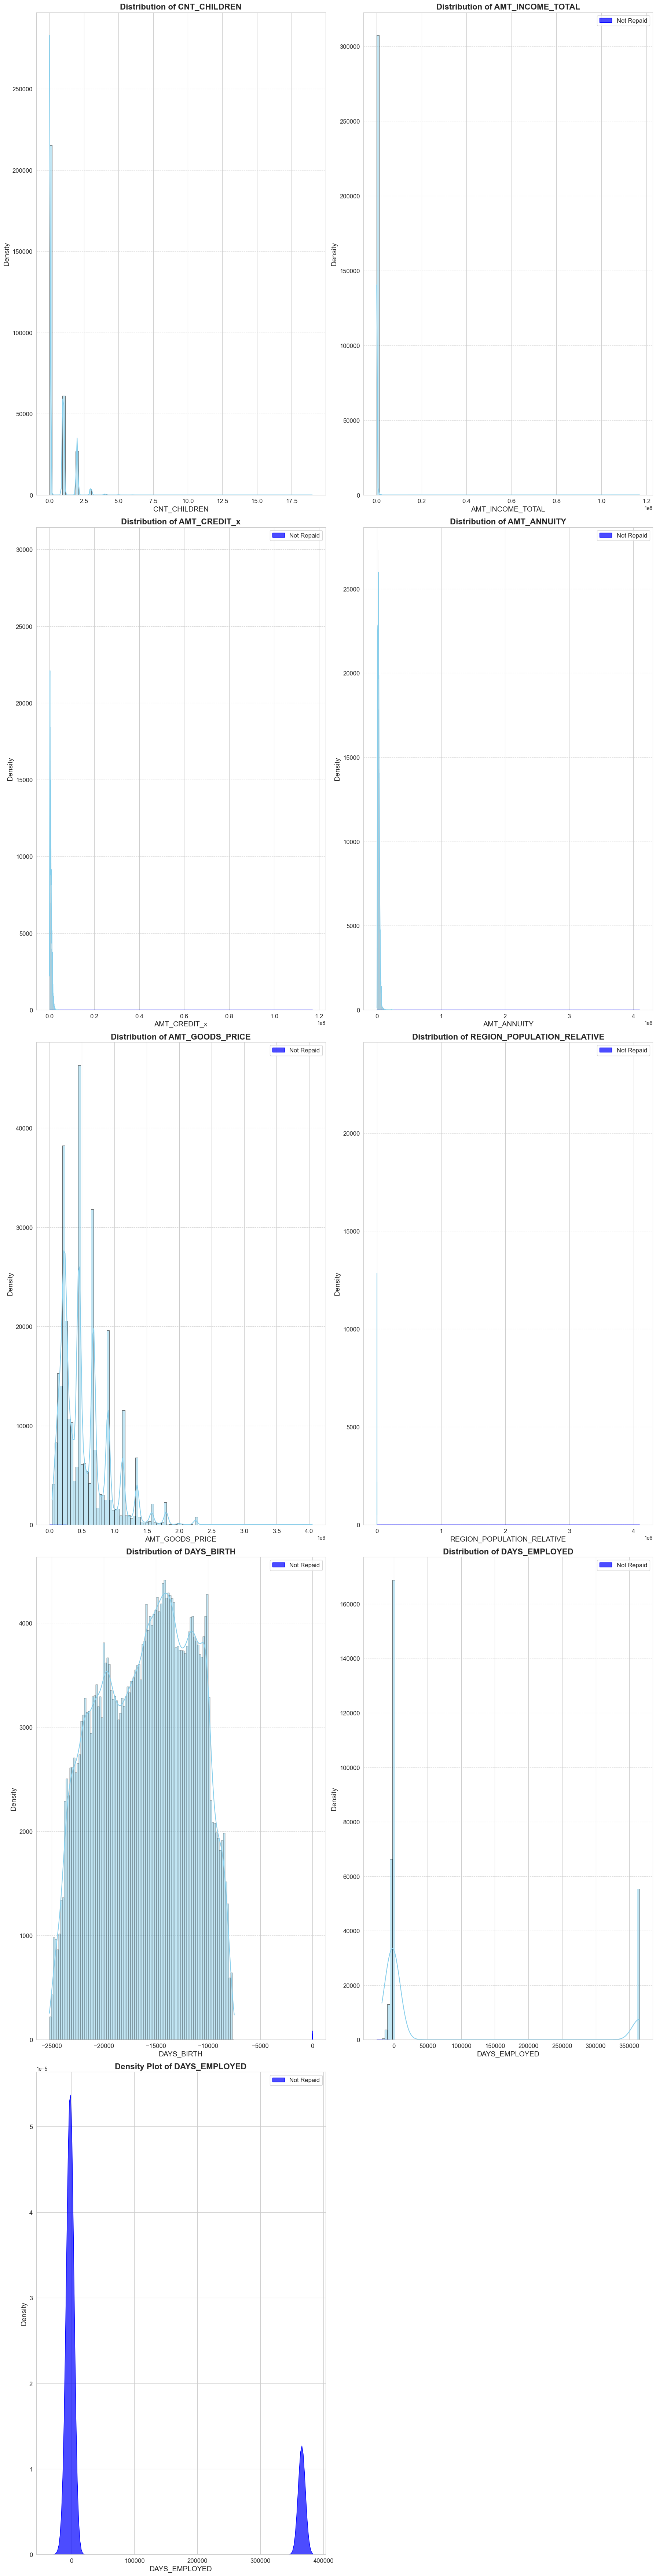

In [57]:
var = ['CNT_CHILDREN', 'AMT_INCOME_TOTAL',
       'AMT_CREDIT_x', 'AMT_ANNUITY', 'AMT_GOODS_PRICE',
       'REGION_POPULATION_RELATIVE', 'DAYS_BIRTH', 'DAYS_EMPLOYED']

plot_distribution_continous(app_train, var)

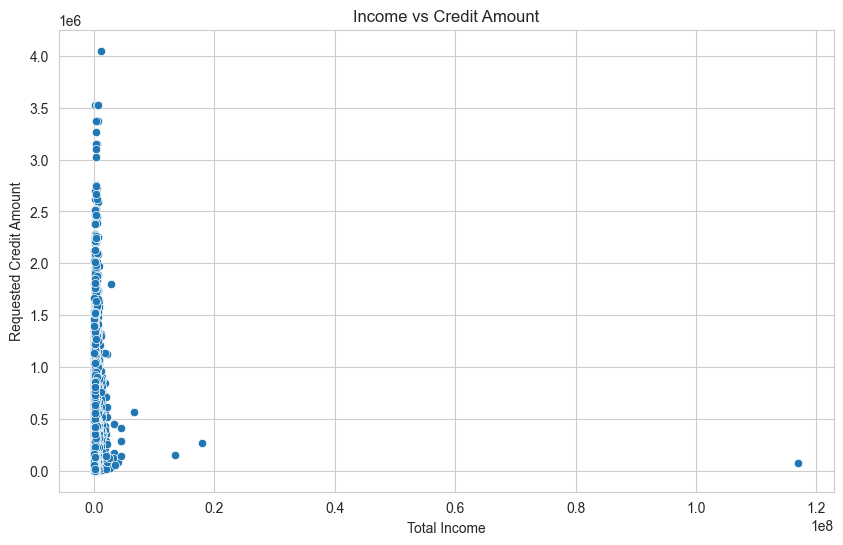

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(x='AMT_INCOME_TOTAL', y='AMT_CREDIT_y', data=app_train)

plt.title('Income vs Credit Amount')
plt.xlabel('Total Income')
plt.ylabel('Requested Credit Amount')

plt.show()

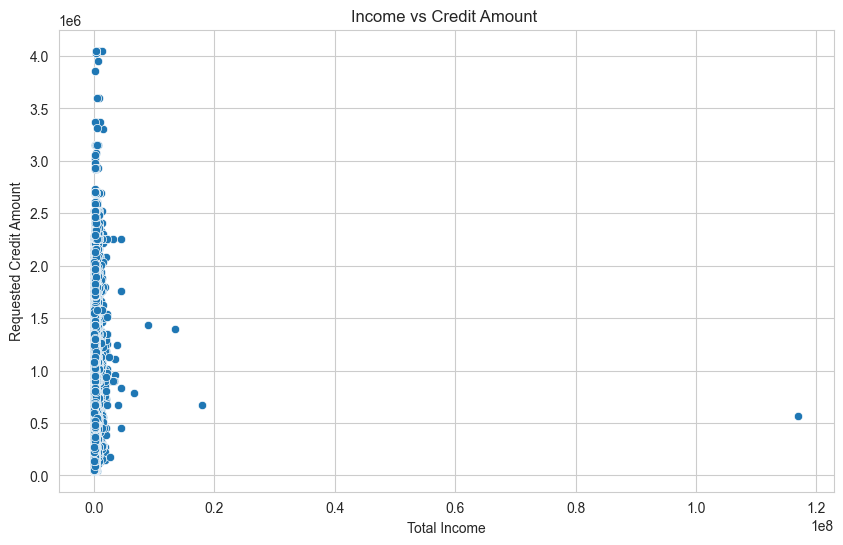

In [59]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='AMT_INCOME_TOTAL', y='AMT_CREDIT_x', data=app_train)
plt.title('Income vs Credit Amount ')
plt.xlabel('Total Income')
plt.ylabel('Requested Credit Amount')
plt.show()

Family and Housing Features
Family Size and Housing Ownership

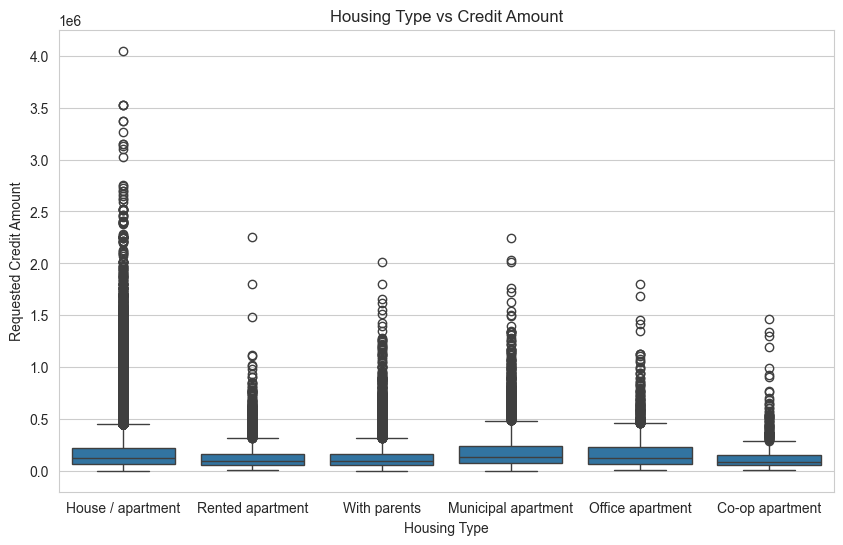

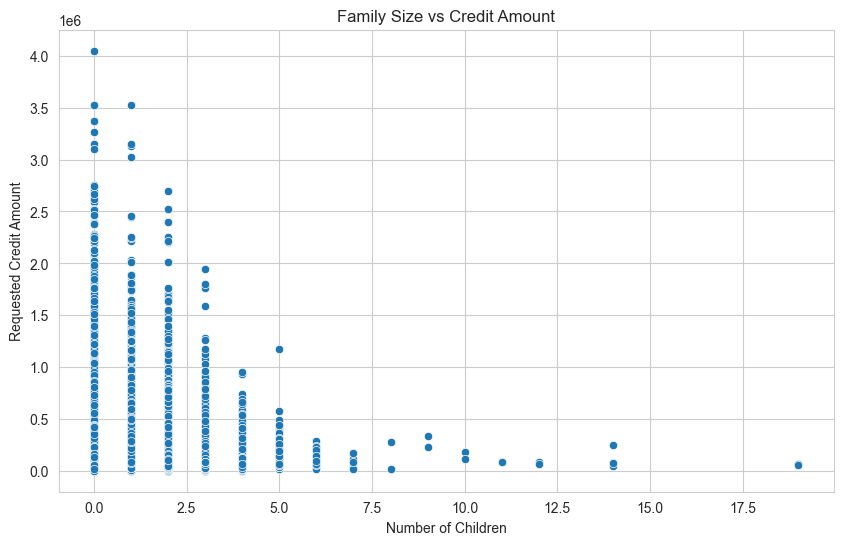

In [60]:
# Investigate Family Size and Housing Ownership
plt.figure(figsize=(10, 6))
sns.boxplot(x='NAME_HOUSING_TYPE', y='AMT_CREDIT_y', data=app_train)
plt.title('Housing Type vs Credit Amount')
plt.xlabel('Housing Type')
plt.ylabel('Requested Credit Amount')
plt.show()

# Family Size Impact vs Default Risk (scatter plot)
plt.figure(figsize=(10, 6))
sns.scatterplot(x='CNT_CHILDREN', y='AMT_CREDIT_y', data=app_train)
plt.title('Family Size vs Credit Amount')
plt.xlabel('Number of Children')
plt.ylabel('Requested Credit Amount')
plt.show()

Employment Duration and Occupation

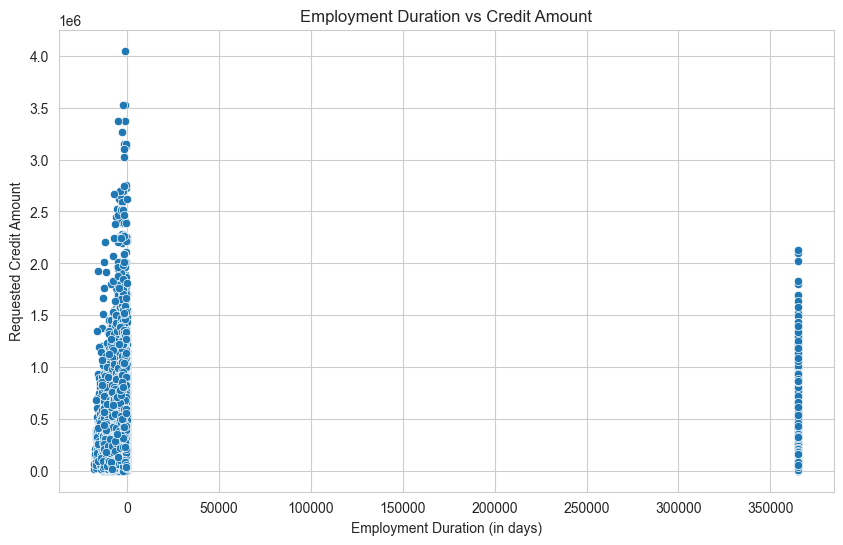

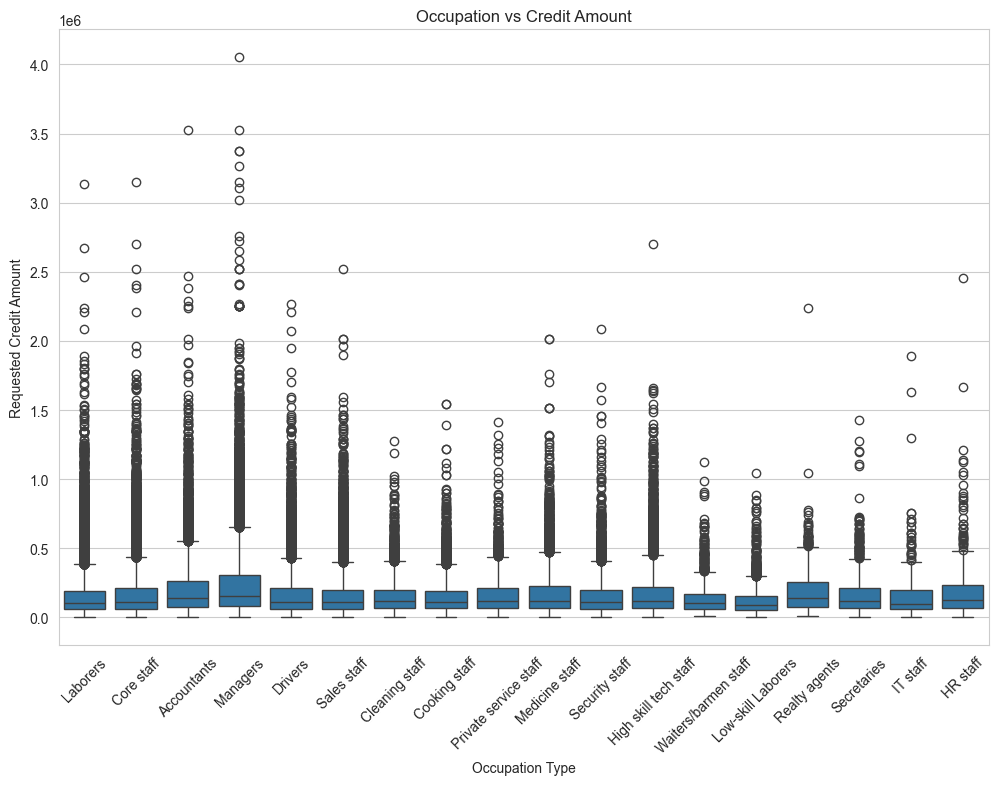

In [61]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='DAYS_EMPLOYED', y='AMT_CREDIT_y', data=app_train)
plt.title('Employment Duration vs Credit Amount')
plt.xlabel('Employment Duration (in days)')
plt.ylabel('Requested Credit Amount')
plt.show()

# Occupation vs Credit Amount
plt.figure(figsize=(12, 8))
sns.boxplot(x='OCCUPATION_TYPE', y='AMT_CREDIT_y', data=app_train)
plt.title('Occupation vs Credit Amount')
plt.xlabel('Occupation Type')
plt.ylabel('Requested Credit Amount')
plt.xticks(rotation=45)
plt.show()


Data Cleaning
Fixing Anomalies and Correct Values
👇 From the previous EDA, I have noticed that most of the time-related features are not in the correct format; hence, I built a list to append all the day-related features to investigate.

In [62]:
day_columns = []
for col in app_train.columns:
    if 'day' in col.lower(): 
        day_columns.append(col)

In [63]:
app_train[day_columns]

,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,WEEKDAY_APPR_PROCESS_START,DAYS_LAST_PHONE_CHANGE,AMT_REQ_CREDIT_BUREAU_DAY,CREDIT_DAY_OVERDUE_max,DAYS_CREDIT_mean,DAYS_CREDIT_min,DAYS_CREDIT_max
0,-9461,-637,-3648.0,-2120,WEDNESDAY,-1134.0,0.0,0.0,-874.000000,-1437.0,-103.0
1,-16765,-1188,-1186.0,-291,MONDAY,-828.0,0.0,0.0,-1400.750000,-2586.0,-606.0
2,-19046,-225,-4260.0,-2531,MONDAY,-815.0,0.0,0.0,-867.000000,-1326.0,-408.0
3,-19005,-3039,-9833.0,-2437,WEDNESDAY,-617.0,NaN,NaN,NaN,NaN,NaN
4,-19932,-3038,-4311.0,-3458,THURSDAY,-1106.0,0.0,0.0,-1149.000000,-1149.0,-1149.0
...,...,...,...,...,...,...,...,...,...,...,...
307506,-9327,-236,-8456.0,-1982,THURSDAY,-273.0,NaN,NaN,NaN,NaN,NaN
307507,-20775,365243,-4388.0,-4090,MONDAY,0.0,NaN,NaN,NaN,NaN,NaN
307508,-14966,-7921,-6737.0,-5150,THURSDAY,-1909.0,0.0,0.0,-867.500000,-919.0,-713.0
307509,-11961,-4786,-2562.0,-931,WEDNESDAY,-322.0,0.0,0.0,-1104.000000,-1104.0,-1104.0


In [64]:
# DAYS_BIRTH
app_train['DAYS_BIRTH'] = app_train['DAYS_BIRTH'].abs()  
app_train['AGE'] = (app_train['DAYS_BIRTH'].abs() / 365.25).astype(int)  
app_train.drop(columns=['DAYS_BIRTH'], inplace=True)

app_test['DAYS_BIRTH'] = app_test['DAYS_BIRTH'].abs()  
app_test['AGE'] = (app_test['DAYS_BIRTH'].abs() / 365.25).astype(int)  
app_test.drop(columns=['DAYS_BIRTH'], inplace=True)

In [65]:
#DAYS_EMPLOYED
app_train['DAYS_EMPLOYED'] = app_train['DAYS_EMPLOYED'].abs()  
app_train['DAYS_EMPLOYED'].replace({365243: np.nan}, inplace=True)
app_train['DAYS_EMPLOYED'].fillna(app_train['DAYS_EMPLOYED'].median(), inplace=True)

app_test['DAYS_EMPLOYED'] = app_test['DAYS_EMPLOYED'].abs()  
app_test['DAYS_EMPLOYED'].replace({365243: np.nan}, inplace=True)
app_test['DAYS_EMPLOYED'].fillna(app_test['DAYS_EMPLOYED'].median(), inplace=True)

In [66]:
day_columns = ['DAYS_REGISTRATION','DAYS_ID_PUBLISH', 'DAYS_LAST_PHONE_CHANGE','DAYS_CREDIT_mean','DAYS_CREDIT_min','DAYS_CREDIT_max']

def handle_anomalies_days(df):
    for col in day_columns:
        if col in df.columns:
            # Convert negative values to positive
            df[col] = df[col].apply(lambda x: abs(x) if x < 0 else x)
            
    return df

In [67]:
app_train = handle_anomalies_days(app_train)
app_test = handle_anomalies_days(app_test)

Here, I thought of going through each column to see if it contains a negative value, and then investigating if it needs handling.

In [68]:
def find_columns_with_negative_values(df):
    
    numerical_columns = df.select_dtypes(include=[np.number]).columns.tolist()
    columns_with_negative_values = []

    for col in numerical_columns:
        if (df[col] < 0).any():  # Check if any value in the column is negative
            columns_with_negative_values.append(col)  # Add to the list if negative values are found

    return columns_with_negative_values

In [69]:
columns_with_negative_values = find_columns_with_negative_values(app_train)

print(columns_with_negative_values)

['AMT_CREDIT_SUM_DEBT_mean', 'AMT_CREDIT_SUM_DEBT_sum', 'INST_PAY_DIFF_MEAN', 'INST_PAY_DIFF_MIN', 'INST_PAY_DIFF_MAX', 'INST_DELAY_MEAN', 'INST_DELAY_MAX', 'AMT_BALANCE']


In [70]:
app_train[columns_with_negative_values]

,AMT_CREDIT_SUM_DEBT_mean,AMT_CREDIT_SUM_DEBT_sum,INST_PAY_DIFF_MEAN,INST_PAY_DIFF_MIN,INST_PAY_DIFF_MAX,INST_DELAY_MEAN,INST_DELAY_MAX,AMT_BALANCE
0,49156.20000,245781.00,0.000000,0.000,0.000,-20.421053,-12.0,NaN
1,0.00000,0.00,0.000000,0.000,0.000,-7.160000,-1.0,NaN
2,0.00000,0.00,0.000000,0.000,0.000,-7.666667,-3.0,NaN
3,NaN,NaN,0.000000,0.000,0.000,-19.375000,-1.0,0.0
4,0.00000,0.00,-452.384318,-22655.655,0.000,-3.636364,12.0,NaN
...,...,...,...,...,...,...,...,...
307506,NaN,NaN,0.000000,0.000,0.000,-36.285714,-8.0,NaN
307507,NaN,NaN,0.000000,0.000,0.000,-2.833333,3.0,NaN
307508,448958.25000,1795833.00,-283.792500,-3945.825,0.000,-14.500000,9.0,NaN
307509,0.00000,0.00,0.000000,0.000,0.000,-19.000000,-8.0,NaN


For some Feature it's not normal to have a negative values, eg, AMT_CREDIT_SUM_DEBT_mean Because it is not normal for credit debt values to be negative. Debt is usually a positive value, indicating the amount owed. While for some other features it's normal to have negative values, eg, INST_PAY_DIFF_MEAN as this feature represents the average difference in installment payments, which is normal Because a negative installment payment difference would indicate that the applicant paid less than the expected installment amount

In [71]:
def handle_negative_values(df):

    columns_with_negative_values_to_handle=['AMT_CREDIT_SUM_DEBT_mean','AMT_CREDIT_SUM_DEBT_sum','INST_DELAY_MEAN','INST_DELAY_MAX','AMT_BALANCE']

    for col in columns_with_negative_values_to_handle:
        if col in df.columns:
            # Set negative values to NaN
            df[col] = df[col].apply(lambda x: x if x >= 0 else np.nan)

    return df

In [72]:
app_train = handle_negative_values(app_train)
app_test = handle_negative_values(app_test)

In [73]:
app_train['CODE_GENDER'].replace('XNA', np.nan, inplace=True)
app_test['CODE_GENDER'].replace('XNA', np.nan, inplace=True)

Missing Values investigation and handling

In [74]:
def missing_values_table(df):

    mis_val = df.isnull().sum()
    mis_val_percent = 100 * mis_val / len(df)

    mis_val_table = pd.concat([mis_val, mis_val_percent], axis=1)
    mis_val_table.columns = ['No. of Missing Values', '% of the Missing Values']

    mis_val_table = mis_val_table[mis_val_table['% of the Missing Values'] > 0].sort_values(
        '% of the Missing Values', ascending=False).round(1)

    print(f"The dataframe has {df.shape[1]} columns.\n"
          f"There are {mis_val_table.shape[0]} columns that have missing values.")
    
    return mis_val_table

In [75]:
missing_values_table(app_train)

The dataframe has 152 columns.
There are 99 columns that have missing values.


,No. of Missing Values,% of the Missing Values
TARGET,307511,100.0
INST_DELAY_MEAN,299143,97.3
AMT_ANNUITY_mean,227502,74.0
AMT_BALANCE,220634,71.7
SK_DPD_y,220606,71.7
...,...,...
AMT_GOODS_PRICE,278,0.1
AMT_ANNUITY,12,0.0
CODE_GENDER,4,0.0
CNT_FAM_MEMBERS,2,0.0


In [76]:
missing_values_table(app_test)

The dataframe has 151 columns.
There are 94 columns that have missing values.


,No. of Missing Values,% of the Missing Values
INST_DELAY_MEAN,47770,98.0
COMMONAREA_AVG,33495,68.7
COMMONAREA_MEDI,33495,68.7
COMMONAREA_MODE,33495,68.7
NONLIVINGAPARTMENTS_AVG,33347,68.4
...,...,...
DEF_30_CNT_SOCIAL_CIRCLE,29,0.1
OBS_60_CNT_SOCIAL_CIRCLE,29,0.1
DEF_60_CNT_SOCIAL_CIRCLE,29,0.1
AMT_ANNUITY,24,0.0


In [77]:
df_train = app_train.copy()
df_test = app_test.copy()

In [78]:
df_train_categorical=df_train.select_dtypes(include='object')
df_train_numerical=df_train.select_dtypes(exclude='object')

df_test_categorical=df_test.select_dtypes(include='object')
df_test_numerical=df_test.select_dtypes(exclude='object')

Handling Missing Values (Categorical)

In [79]:
missing_values_table(df_train_categorical)

The dataframe has 16 columns.
There are 7 columns that have missing values.


,No. of Missing Values,% of the Missing Values
FONDKAPREMONT_MODE,210295,68.4
WALLSMATERIAL_MODE,156341,50.8
HOUSETYPE_MODE,154297,50.2
EMERGENCYSTATE_MODE,145755,47.4
OCCUPATION_TYPE,96391,31.3
NAME_TYPE_SUITE,1292,0.4
CODE_GENDER,4,0.0


In [80]:
missing_values_table(df_test_categorical)

The dataframe has 16 columns.
There are 6 columns that have missing values.


,No. of Missing Values,% of the Missing Values
FONDKAPREMONT_MODE,32797,67.3
WALLSMATERIAL_MODE,23893,49.0
HOUSETYPE_MODE,23619,48.5
EMERGENCYSTATE_MODE,22209,45.6
OCCUPATION_TYPE,15605,32.0
NAME_TYPE_SUITE,911,1.9


In [81]:
# Delete Features with more than 50 % missing

df_train.drop(columns=['FONDKAPREMONT_MODE','WALLSMATERIAL_MODE','HOUSETYPE_MODE','EMERGENCYSTATE_MODE'], inplace=True)
df_test.drop(columns=['FONDKAPREMONT_MODE','WALLSMATERIAL_MODE','HOUSETYPE_MODE','EMERGENCYSTATE_MODE'], inplace=True)

In [82]:
# impute other catergorical columns

# 1- impute the OCCUPATION_TYPE with random imputation (18 different job)

missing = df_train['OCCUPATION_TYPE'].isna()
categories = df_train['OCCUPATION_TYPE'].dropna().unique()

imputed_values = np.random.choice(categories, size=missing.sum(), replace=True)
df_train.loc[missing, 'OCCUPATION_TYPE'] = imputed_values
# test date
df_test['OCCUPATION_TYPE']=df_test['OCCUPATION_TYPE'].fillna(np.random.choice(categories))

# 2- impute the NAME_TYPE_SUITE with the mode

mode_value = df_train['NAME_TYPE_SUITE'].mode()[0]
df_train['NAME_TYPE_SUITE'].fillna(mode_value, inplace=True)
# test date
df_test['NAME_TYPE_SUITE'].fillna(mode_value, inplace=True)

# 3- impute the CODE_GENDER with the mode

mode_value = df_train['CODE_GENDER'].mode()[0]
df_train['CODE_GENDER'].fillna(mode_value, inplace=True)

Handling Missing Values (numerical)

In [83]:
df_train

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT_x,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,TOTALAREA_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,AMT_CREDIT_SUM_mean,AMT_CREDIT_SUM_sum,AMT_CREDIT_SUM_OVERDUE_mean,AMT_CREDIT_SUM_OVERDUE_sum,AMT_CREDIT_SUM_DEBT_mean,AMT_CREDIT_SUM_DEBT_sum,CREDIT_ACTIVE_<lambda>,CREDIT_DAY_OVERDUE_max,AMT_ANNUITY_mean,AMT_ANNUITY_sum,DAYS_CREDIT_mean,DAYS_CREDIT_min,DAYS_CREDIT_max,CREDIT_TYPE_nunique,SK_ID_PREV_x,NAME_CONTRACT_STATUS,AMT_APPLICATION,AMT_CREDIT_y,INST_CNT,INST_PAY_DIFF_MEAN,INST_PAY_DIFF_MIN,INST_PAY_DIFF_MAX,INST_DELAY_MEAN,INST_DELAY_MAX,INST_TOTAL_PAID,INST_TOTAL_DUE,SK_ID_PREV_y,SK_DPD_x,AMT_BALANCE,SK_DPD_y,AGE
0,100002,NaN,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,351000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.018801,637.0,3648.0,2120,NaN,1,1,0,1,1,0,Laborers,1.0,2,2,WEDNESDAY,10,0,0,0,0,0,0,Business Entity Type 3,0.083037,0.262949,0.139376,0.0247,0.0369,0.9722,0.6192,0.0143,0.00,0.0690,0.0833,0.1250,0.0369,0.0202,0.0190,0.0000,0.0000,0.0252,0.0383,0.9722,0.6341,0.0144,0.0000,0.0690,0.0833,0.1250,0.0377,0.0220,0.0198,0.0,0.0000,0.0250,0.0369,0.9722,0.6243,0.0144,0.00,0.0690,0.0833,0.1250,0.0375,0.0205,0.0193,0.0000,0.0000,0.0149,2.0,2.0,2.0,2.0,1134.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0,108131.945625,865055.565,0.0,0.0,49156.20000,245781.00,2.0,0.0,0.0,0.0,874.000000,1437.0,103.0,2.0,1.0,1.0,179055.000,179055.00,19.0,0.000000,0.000,0.000,NaN,NaN,219625.695,219625.695,1.0,0.0,NaN,NaN,25
1,100003,NaN,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,1129500.0,Family,State servant,Higher education,Married,House / apartment,0.003541,1188.0,1186.0,291,NaN,1,1,0,1,1,0,Core staff,2.0,1,1,MONDAY,11,0,0,0,0,0,0,School,0.311267,0.622246,NaN,0.0959,0.0529,0.9851,0.7960,0.0605,0.08,0.0345,0.2917,0.3333,0.0130,0.0773,0.0549,0.0039,0.0098,0.0924,0.0538,0.9851,0.8040,0.0497,0.0806,0.0345,0.2917,0.3333,0.0128,0.0790,0.0554,0.0,0.0000,0.0968,0.0529,0.9851,0.7987,0.0608,0.08

In [84]:
df_test

,SK_ID_CURR,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT_x,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,TOTALAREA_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,AMT_CREDIT_SUM_mean,AMT_CREDIT_SUM_sum,AMT_CREDIT_SUM_OVERDUE_mean,AMT_CREDIT_SUM_OVERDUE_sum,AMT_CREDIT_SUM_DEBT_mean,AMT_CREDIT_SUM_DEBT_sum,CREDIT_ACTIVE_<lambda>,CREDIT_DAY_OVERDUE_max,AMT_ANNUITY_mean,AMT_ANNUITY_sum,DAYS_CREDIT_mean,DAYS_CREDIT_min,DAYS_CREDIT_max,CREDIT_TYPE_nunique,SK_ID_PREV_x,NAME_CONTRACT_STATUS,AMT_APPLICATION,AMT_CREDIT_y,INST_CNT,INST_PAY_DIFF_MEAN,INST_PAY_DIFF_MIN,INST_PAY_DIFF_MAX,INST_DELAY_MEAN,INST_DELAY_MAX,INST_TOTAL_PAID,INST_TOTAL_DUE,SK_ID_PREV_y,SK_DPD_x,AMT_BALANCE,SK_DPD_y,AGE
0,100001,Cash loans,F,N,Y,0,135000.0,568800.0,20560.5,450000.0,Unaccompanied,Working,Higher education,Married,House / apartment,0.018850,2329.0,5170.0,812,NaN,1,1,0,1,0,1,Managers,2.0,2,2,TUESDAY,18,0,0,0,0,0,0,Kindergarten,0.752614,0.789654,0.159520,0.0660,0.0590,0.9732,NaN,NaN,NaN,0.1379,0.1250,NaN,NaN,NaN,0.0505,NaN,NaN,0.0672,0.0612,0.9732,NaN,NaN,NaN,0.1379,0.1250,NaN,NaN,NaN,0.0526,NaN,NaN,0.0666,0.0590,0.9732,NaN,NaN,NaN,0.1379,0.1250,NaN,NaN,NaN,0.0514,NaN,NaN,0.0392,0.0,0.0,0.0,0.0,1740.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,2.076236e+05,1453365.00,0.0,0.0,85240.928571,596686.500,3.0,0.0,3545.357143,24817.500,735.000000,1572.0,49.0,1.0,1.0,1.0,24835.5000,23787.0000,7.0,0.000000,0.00,0.0,NaN,11.0,41195.925,41195.925,2.0,7.0,NaN,NaN,52
1,100005,Cash loans,M,N,Y,0,99000.0,222768.0,17370.0,180000.0,Unaccompanied,Working,Secondary / secondary special,Married,House / apartment,0.035792,4469.0,9118.0,1623,NaN,1,1,0,1,0,0,Low-skill Laborers,2.0,2,2,FRIDAY,9,0,0,0,0,0,0,Self-employed,0.564990,0.291656,0.432962,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,3.0,2.190420e+05,657126.00,0.0,0.0,189469.500000,568408

Check Feature Correlation and handling multicollinearity

In [85]:
threshold = 0.8

train_corr = df_train_numerical.corr().abs()
train_corr.head()

,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT_x,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,TOTALAREA_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,AMT_CREDIT_SUM_mean,AMT_CREDIT_SUM_sum,AMT_CREDIT_SUM_OVERDUE_mean,AMT_CREDIT_SUM_OVERDUE_sum,AMT_CREDIT_SUM_DEBT_mean,AMT_CREDIT_SUM_DEBT_sum,CREDIT_ACTIVE_<lambda>,CREDIT_DAY_OVERDUE_max,AMT_ANNUITY_mean,AMT_ANNUITY_sum,DAYS_CREDIT_mean,DAYS_CREDIT_min,DAYS_CREDIT_max,CREDIT_TYPE_nunique,SK_ID_PREV_x,NAME_CONTRACT_STATUS,AMT_APPLICATION,AMT_CREDIT_y,INST_CNT,INST_PAY_DIFF_MEAN,INST_PAY_DIFF_MIN,INST_PAY_DIFF_MAX,INST_DELAY_MEAN,INST_DELAY_MAX,INST_TOTAL_PAID,INST_TOTAL_DUE,SK_ID_PREV_y,SK_DPD_x,AMT_BALANCE,SK_DPD_y,AGE
SK_ID_CURR,1.000000,NaN,0.001129,0.001820,0.000343,0.000433,0.000232,0.000849,0.000105,0.000973,0.000384,0.001818,0.002804,0.001337,0.000415,0.002815,0.002753,0.000281,0.002895,0.001075,0.001138,0.000350,0.000283,0.001097,0.002903,0.001885,0.001582,0.000067,0.000082,0.002342,0.000222,0.001556,0.002070,0.001551,0.005900,0.001463,0.004862,0.002879,0.004851,0.003083,0.001465,0.003119,0.001770,0.002575,0.003042,0.001961,0.001411,0.001890,0.005245,0.001058,0.005017,0.002844,0.004386,0.002081,0.001548,0.003589,0.002156,0.001923,0.001920,0.001988,0.001647,0.001366,0.005777,0.001036,0.005067,0.002583,0.004588,0.002837,0.001699,0.003272,0.002205,0.003020,0.002440,0.002288,0.001409,0.000082,0.001423,0.001187,0.000858,0.000700,0.003411,0.004139,0.001097,0.002121,0.002694,0.001809,0.001505,0.000815,0.002012,0.001045,0.000896,0.001077,0.002604,0.000724,0.001450,0.000509,0.000167,0.001073,0.000282,0.002672,0.002193,0.002099,0.000485,0.001025,0.004659,0.001405,0.003087,0.001797,0.000373,0.001043,0.000598,0.002397,0.000679,0.007596,0.005771,0.003636,0.001008,0.005079,0.003714,0.003001,0.001777,0.000869,0.001204,0.002997,0.002179,0.003025,0.001262,0.002628,0.003718,0.002289,0.001964,0.002149,0.003522,0.001913,0.001929,0.001440
TARGET,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN

In [86]:
to_drop = []

for i in range(len(train_corr.columns)):
    for j in range(i):
        if train_corr.iloc[i, j] > threshold:
            colname = train_corr.columns[i]
            if colname not in to_drop:  # Only add once
                to_drop.append(colname)

print('There are %d columns to remove.' % len(to_drop))

There are 43 columns to remove.


In [87]:
df_train.drop(columns=to_drop, inplace=True)
df_test.drop(columns=to_drop, inplace=True)

In [88]:
missing_values_table(df_train)

The dataframe has 105 columns.
There are 52 columns that have missing values.


,No. of Missing Values,% of the Missing Values
TARGET,307511,100.0
INST_DELAY_MEAN,299143,97.3
AMT_ANNUITY_mean,227502,74.0
AMT_BALANCE,220634,71.7
SK_DPD_y,220606,71.7
COMMONAREA_AVG,214865,69.9
NONLIVINGAPARTMENTS_AVG,213514,69.4
FLOORSMIN_AVG,208642,67.8
YEARS_BUILD_AVG,204488,66.5
OWN_CAR_AGE,202929,66.0


In [89]:
missing_values_table(df_test)

The dataframe has 104 columns.
There are 50 columns that have missing values.


,No. of Missing Values,% of the Missing Values
INST_DELAY_MEAN,47770,98.0
COMMONAREA_AVG,33495,68.7
NONLIVINGAPARTMENTS_AVG,33347,68.4
FLOORSMIN_AVG,32466,66.6
OWN_CAR_AGE,32312,66.3
AMT_BALANCE,32099,65.9
SK_DPD_y,32091,65.8
YEARS_BUILD_AVG,31818,65.3
LANDAREA_AVG,28254,58.0
BASEMENTAREA_AVG,27641,56.7


Since the data still contains a huge amount of missing data, it's a valid approach to drop features with more than 45 % missing values

In [90]:
train_missing = (df_train.isnull().sum() / len(df_train)).sort_values(ascending = False)
test_missing = (df_test.isnull().sum() / len(df_test)).sort_values(ascending = False)


train_missing = train_missing.index[train_missing > 0.45]
test_missing = test_missing.index[test_missing > 0.45]

all_missing = list(set(set(train_missing) | set(test_missing)))
print('There are %d columns with more than 50%% missing values' % len(all_missing))

There are 18 columns with more than 50% missing values


In [93]:
# Remove TARGET if accidentally included
if 'TARGET' in all_missing:
    all_missing.remove('TARGET')

# Keep only valid columns
cols_to_drop = [col for col in all_missing if col in df_train.columns]

# Drop safely
df_train.drop(columns=cols_to_drop, inplace=True)
df_test.drop(columns=cols_to_drop, inplace=True)

In [98]:
missing_values_table(df_train)

The dataframe has 87 columns.
There are 34 columns that have missing values.


,No. of Missing Values,% of the Missing Values
INST_DELAY_MAX,108352,35.2
EXT_SOURCE_3,60965,19.8
AMT_CREDIT_SUM_DEBT_mean,52676,17.1
AMT_CREDIT_SUM_DEBT_sum,45316,14.7
AMT_CREDIT_SUM_mean,44021,14.3
DAYS_CREDIT_mean,44020,14.3
CREDIT_DAY_OVERDUE_max,44020,14.3
AMT_CREDIT_SUM_sum,44020,14.3
AMT_CREDIT_SUM_OVERDUE_mean,44020,14.3
AMT_CREDIT_SUM_OVERDUE_sum,44020,14.3


In [99]:
missing_values_table(df_test)

The dataframe has 104 columns.
There are 50 columns that have missing values.


,No. of Missing Values,% of the Missing Values
INST_DELAY_MEAN,47770,98.0
COMMONAREA_AVG,33495,68.7
NONLIVINGAPARTMENTS_AVG,33347,68.4
FLOORSMIN_AVG,32466,66.6
OWN_CAR_AGE,32312,66.3
AMT_BALANCE,32099,65.9
SK_DPD_y,32091,65.8
YEARS_BUILD_AVG,31818,65.3
LANDAREA_AVG,28254,58.0
BASEMENTAREA_AVG,27641,56.7


 I will impute those features with the best way i think they can be imputed

I would recommend using KNN imputer; however, for the time and resources limitations I currently have, I will impute with regular fillna techniques

In [100]:
missing_train_cols = [col for col in df_train.columns if df_train[col].isnull().any()]
missing_test_cols = [col for col in df_test.columns if df_test[col].isnull().any()]

In [101]:
len(missing_train_cols), len(missing_test_cols)

(34, 50)

In [102]:
common_missing_cols = list(set(missing_train_cols) & set(missing_test_cols))

# Print the results
print("Columns with missing values in both datasets:")
print(common_missing_cols)

print("\nColumns with missing values in train dataset:")
print(list(set(missing_train_cols) - set(missing_test_cols)))

print("\nColumns with missing values in test dataset:")
print(list(set(missing_test_cols) - set(missing_train_cols)))

Columns with missing values in both datasets:
['INST_DELAY_MAX', 'DAYS_CREDIT_max', 'AMT_CREDIT_SUM_OVERDUE_sum', 'CREDIT_TYPE_nunique', 'AMT_CREDIT_SUM_sum', 'AMT_ANNUITY_sum', 'AMT_REQ_CREDIT_BUREAU_YEAR', 'DEF_30_CNT_SOCIAL_CIRCLE', 'NAME_CONTRACT_STATUS', 'CREDIT_ACTIVE_<lambda>', 'INST_PAY_DIFF_MIN', 'AMT_REQ_CREDIT_BUREAU_WEEK', 'SK_DPD_x', 'AMT_CREDIT_SUM_DEBT_sum', 'INST_CNT', 'EXT_SOURCE_3', 'OBS_30_CNT_SOCIAL_CIRCLE', 'AMT_REQ_CREDIT_BUREAU_QRT', 'INST_PAY_DIFF_MEAN', 'CREDIT_DAY_OVERDUE_max', 'AMT_CREDIT_SUM_DEBT_mean', 'AMT_APPLICATION', 'AMT_ANNUITY', 'DAYS_CREDIT_mean', 'SK_ID_PREV_x', 'AMT_CREDIT_SUM_OVERDUE_mean', 'INST_TOTAL_PAID', 'AMT_REQ_CREDIT_BUREAU_DAY', 'INST_PAY_DIFF_MAX', 'AMT_CREDIT_SUM_mean', 'AMT_REQ_CREDIT_BUREAU_HOUR', 'EXT_SOURCE_2', 'AMT_REQ_CREDIT_BUREAU_MON']

Columns with missing values in train dataset:
['DAYS_LAST_PHONE_CHANGE']

Columns with missing values in test dataset:
['NONLIVINGAREA_AVG', 'EXT_SOURCE_1', 'COMMONAREA_AVG', 'FLOORSMIN_AVG', 'I

 Imputation logic based on domain relevance and typical distribution characteristics

In [103]:
def impute_data(df):

    # 0-imputation for count or flag features
    zero_fill_features = [
        'DEF_30_CNT_SOCIAL_CIRCLE',
        'AMT_REQ_CREDIT_BUREAU_QRT',
        'AMT_REQ_CREDIT_BUREAU_MON',
        'CREDIT_ACTIVE_<lambda>',
        'AMT_REQ_CREDIT_BUREAU_HOUR',
        'AMT_REQ_CREDIT_BUREAU_WEEK',
        'AMT_REQ_CREDIT_BUREAU_DAY',
        'AMT_REQ_CREDIT_BUREAU_YEAR',
        'SK_ID_PREV_x',
        'SK_DPD_x',
        'OBS_30_CNT_SOCIAL_CIRCLE'
    ]
    for col in zero_fill_features:
        if col in df.columns:
            df[col].fillna(0, inplace=True)

    # Median imputation for monetary and delay/time-based features
    median_fill_features = [
        'CREDIT_DAY_OVERDUE_max',
        'AMT_CREDIT_SUM_sum',
        'INST_TOTAL_PAID',
        'AMT_APPLICATION',
        'DAYS_CREDIT_mean',
        'DAYS_CREDIT_max',
        'AMT_CREDIT_SUM_OVERDUE_mean',
        'AMT_CREDIT_SUM_OVERDUE_sum',
        'AMT_CREDIT_SUM_DEBT_sum',
        'AMT_CREDIT_SUM_DEBT_mean',
        'INST_DELAY_MAX',
        'INST_PAY_DIFF_MEAN',
        'INST_PAY_DIFF_MIN',
        'INST_PAY_DIFF_MAX',
        'AMT_CREDIT_SUM_mean',
        'AMT_ANNUITY_sum',
        'AMT_ANNUITY',
        'INST_CNT',
        'EXT_SOURCE_2',
        'EXT_SOURCE_3'
    ]
    for col in median_fill_features:
        if col in df.columns:
            df[col].fillna(df[col].median(), inplace=True)

    # Mode imputation for categorical/ordinal features
    if 'NAME_CONTRACT_STATUS' in df.columns:
        df['NAME_CONTRACT_STATUS'].fillna(df['NAME_CONTRACT_STATUS'].mode()[0], inplace=True)

    if 'CREDIT_TYPE_nunique' in df.columns:
        df['CREDIT_TYPE_nunique'].fillna(df['CREDIT_TYPE_nunique'].mode()[0], inplace=True)

    return df

In [104]:
df_train['DAYS_LAST_PHONE_CHANGE'].fillna(df_train['DAYS_LAST_PHONE_CHANGE'].median(), inplace=True)

In [105]:
df_train = impute_data(df_train)

In [106]:
df_test = impute_data(df_test)

In [107]:
missing_values_table(df_train)

The dataframe has 87 columns.
There are 0 columns that have missing values.


,No. of Missing Values,% of the Missing Values


In [108]:
missing_values_table(df_test)

The dataframe has 104 columns.
There are 17 columns that have missing values.


,No. of Missing Values,% of the Missing Values
INST_DELAY_MEAN,47770,98.0
COMMONAREA_AVG,33495,68.7
NONLIVINGAPARTMENTS_AVG,33347,68.4
FLOORSMIN_AVG,32466,66.6
OWN_CAR_AGE,32312,66.3
AMT_BALANCE,32099,65.9
SK_DPD_y,32091,65.8
YEARS_BUILD_AVG,31818,65.3
LANDAREA_AVG,28254,58.0
BASEMENTAREA_AVG,27641,56.7


In [109]:
df_train.columns = df_train.columns.str.replace(r'[^a-zA-Z0-9_]', '_', regex=True)
df_test.columns = df_test.columns.str.replace(r'[^a-zA-Z0-9_]', '_', regex=True)

resolving column names, not to encounter the issue with JSON special characters

Encoding

In [110]:
le = LabelEncoder()
counter = 0

for col in df_train:
    if df_train[col].dtype == 'object':
        if len(list(df_train[col].unique())) <= 2:
            le.fit(df_train[col])
            df_train[col] = le.transform(df_train[col])
            df_test[col] = le.transform(df_test[col])
            
            counter += 1
            
print('%d columns were label encoded.' % counter)

4 columns were label encoded.


In [111]:
# one-hot-encoding

df_train = pd.get_dummies(df_train)
df_test = pd.get_dummies(df_test)

print('Training Features shape: ', df_train.shape)
print('Testing Features shape: ', df_test.shape)

Training Features shape:  (307511, 194)
Testing Features shape:  (48744, 209)


Aligning, to keep only features present in both dataframes

In [113]:
# Separate target
train_labels = df_train['TARGET']

# Drop target before alignment
df_train = df_train.drop(columns=['TARGET'])

# Align
df_train, df_test = df_train.align(df_test, join='inner', axis=1)

# Add target back
df_train['TARGET'] = train_labels

KeyError: 'TARGET'

In [114]:
print('TARGET' in df_train.columns)

False


In [118]:
train_labels = app_train['TARGET']

In [119]:
# Align without TARGET
df_train, df_test = df_train.align(df_test, join='inner', axis=1)

# Add TARGET back
df_train['TARGET'] = train_labels

In [117]:
# Step 1: Separate target
train_labels = df_train['TARGET']

# Step 2: Drop target
df_train = df_train.drop(columns=['TARGET'])

# Step 3: Align
df_train, df_test = df_train.align(df_test, join='inner', axis=1)

# Step 4: Add back
df_train['TARGET'] = train_labels

In [120]:
# Always take from original data
train_labels = app_train['TARGET']

# Align features
df_train, df_test = df_train.align(df_test, join='inner', axis=1)

# Add target back
df_train['TARGET'] = train_labels

In [121]:
print('TARGET' in df_train.columns)  # Should be True
print(df_train.shape)
print(df_test.shape)

True
(307511, 193)
(48744, 192)


In [122]:
train_labels = df_train['TARGET']

df_train, df_test = df_train.align(df_test, join = 'inner', axis = 1)

df_train['TARGET'] = train_labels

print('Training Features shape: ', df_train.shape)
print('Testing Features shape: ', df_test.shape)

Training Features shape:  (307511, 193)
Testing Features shape:  (48744, 192)


Modeling
Spliting

In [123]:
TARGET = 'TARGET'
ID = 'SK_ID_CURR'

In [124]:
features = [col for col in df_train.columns if col not in [TARGET, ID]]
X = df_train[features]
y = df_train[TARGET]
X_test = df_test[features]

In [125]:
X.columns = X.columns.str.replace(r'[^a-zA-Z0-9_]', '_', regex=True)
X_test.columns = X_test.columns.str.replace(r'[^a-zA-Z0-9_]', '_', regex=True)

In [347]:
num_folds = 5
stratified = True  
debug = False
final_file_name = "final_lgbm.csv"

In [127]:
print(f"Training data shape: {X.shape}")
print(f"Test data shape: {X_test.shape}")
print(f"Number of features: {len(features)}")
print(f"Target distribution: {y.value_counts().sort_index()}")

Training data shape: (307511, 191)
Test data shape: (48744, 191)
Number of features: 191
Target distribution: Series([], Name: count, dtype: int64)


Setup Cross-Validation

In [128]:
if stratified:
    folds = StratifiedKFold(n_splits=num_folds, shuffle=True, random_state=1001)
    print(f"Using Stratified {num_folds}-fold cross-validation")
else:
    folds = KFold(n_splits=num_folds, shuffle=True, random_state=1001)
    print(f"Using Regular {num_folds}-fold cross-validation")

# Initialize result containers
oof_preds = np.zeros(X.shape[0])  # Out-of-fold predictions
test_preds = np.zeros(X_test.shape[0])  # Test set predictions
feature_importance_df = pd.DataFrame()

print("Cross-validation setup completed")

Using Stratified 5-fold cross-validation
Cross-validation setup completed


Cross-Validation Training Loop

In [130]:
print(y.isnull().sum())

307511


In [131]:
# Step 1: Save target with reset index
train_labels = df_train['TARGET'].reset_index(drop=True)

# Step 2: Drop target and reset index
df_train = df_train.drop(columns=['TARGET']).reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

# Step 3: Align datasets
df_train, df_test = df_train.align(df_test, join='left', axis=1, fill_value=0)

# Step 4: Add target back
df_train['TARGET'] = train_labels

In [132]:
print(df_train['TARGET'].isnull().sum())

307511


In [133]:
print(train_labels.head())
print(train_labels.isnull().sum())
print(train_labels.shape)

0   NaN
1   NaN
2   NaN
3   NaN
4   NaN
Name: TARGET, dtype: float64
307511
(307511,)


In [137]:
df_train = pd.get_dummies(df_train)

In [138]:
print('TARGET in columns:', 'TARGET' in df_train.columns)
print(df_train.filter(like='TARGET').head())

TARGET in columns: True
   TARGET
0     NaN
1     NaN
2     NaN
3     NaN
4     NaN


In [139]:
print(df_train['TARGET'].isnull().sum())


307511


In [142]:
y = df_train['TARGET']
X = df_train.drop(columns=['TARGET'])

In [143]:
print(y.isnull().sum())  # should be 0

307511


In [146]:
df_train = pd.read_csv('home-credit-default-risk/application_train.csv')

print(df_train['TARGET'].head())
print(df_train['TARGET'].isnull().sum())

0    1
1    0
2    0
3    0
4    0
Name: TARGET, dtype: int64
0


In [148]:
y = df_train['TARGET']
X = df_train.drop(columns=['TARGET'])

print(y.isnull().sum())  # must be 0

0


In [150]:
X = pd.get_dummies(X)

df_test = pd.read_csv('home-credit-default-risk/application_test.csv')
df_test = pd.get_dummies(df_test)

In [151]:
X, df_test = X.align(df_test, join='left', axis=1, fill_value=0)

In [152]:
folds.split(X, y)  # ✅ works

<generator object _BaseKFold.split at 0x000001C48747E570>

In [153]:
for train_idx, valid_idx in folds.split(X, y):
    print("Train:", len(train_idx), "Valid:", len(valid_idx))
    break

Train: 246008 Valid: 61503


In [155]:
import re

def clean_feature_names(df):
    df.columns = [
        re.sub(r'[^A-Za-z0-9_]+', '_', col)
        for col in df.columns
    ]
    return df

# Apply to both
X = clean_feature_names(X)
df_test = clean_feature_names(df_test)

In [156]:
[col for col in X.columns if any(c in col for c in ['[', ']', '{', '}', '"', "'"])]

[]

In [157]:
X.columns = X.columns.str.replace('[^A-Za-z0-9_]', '_', regex=True)
df_test.columns = df_test.columns.str.replace('[^A-Za-z0-9_]', '_', regex=True)

In [158]:
X = X.loc[:, ~X.columns.duplicated()]
df_test = df_test.loc[:, ~df_test.columns.duplicated()]

In [159]:
# Clean column names
X.columns = X.columns.str.replace('[^A-Za-z0-9_]', '_', regex=True)
df_test.columns = df_test.columns.str.replace('[^A-Za-z0-9_]', '_', regex=True)

# Remove duplicates
X = X.loc[:, ~X.columns.duplicated()]
df_test = df_test.loc[:, ~df_test.columns.duplicated()]

In [161]:
X, df_test = X.align(df_test, join='left', axis=1, fill_value=0)

In [162]:
df_test = df_test[X.columns]

In [163]:
print(X.shape)
print(df_test.shape)
print((X.columns == df_test.columns).all())

(307511, 245)
(48744, 245)
True


In [165]:
# 1. Separate
y = df_train['TARGET']
X = df_train.drop(columns=['TARGET'])

# 2. Encode
X = pd.get_dummies(X)
df_test = pd.get_dummies(df_test)

# 3. Align
X, df_test = X.align(df_test, join='left', axis=1, fill_value=0)

# 4. Clean column names
X.columns = X.columns.str.replace('[^A-Za-z0-9_]', '_', regex=True)
df_test.columns = df_test.columns.str.replace('[^A-Za-z0-9_]', '_', regex=True)

# 5. Remove duplicates
X = X.loc[:, ~X.columns.duplicated()]
df_test = df_test.loc[:, ~df_test.columns.duplicated()]

# 6. FINAL ALIGN (VERY IMPORTANT)
X, df_test = X.align(df_test, join='left', axis=1, fill_value=0)

# 7. Ensure same order
df_test = df_test[X.columns]

In [168]:
test_preds += clf.predict_proba(df_test)[:, 1] / folds.n_splits

In [169]:
print(X.shape)
print(df_test.shape)
print(X_test.shape)

(307511, 245)
(48744, 245)
(48744, 191)


In [170]:
df_test

,SK_ID_CURR,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,TOTALAREA_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,NAME_CONTRACT_TYPE_Cash_loans,NAME_CONTRACT_TYPE_Revolving_loans,CODE_GENDER_F,CODE_GENDER_M,CODE_GENDER_XNA,FLAG_OWN_CAR_N,FLAG_OWN_CAR_Y,FLAG_OWN_REALTY_N,FLAG_OWN_REALTY_Y,NAME_TYPE_SUITE_Children,NAME_TYPE_SUITE_Family,NAME_TYPE_SUITE_Group_of_people,NAME_TYPE_SUITE_Other_A,NAME_TYPE_SUITE_Other_B,NAME_TYPE_SUITE_Spouse__partner,NAME_TYPE_SUITE_Unaccompanied,NAME_INCOME_TYPE_Businessman,NAME_INCOME_TYPE_Commercial_associate,NAME_INCOME_TYPE_Maternity_leave,NAME_INCOME_TYPE_Pensioner,NAME_INCOME_TYPE_State_servant,NAME_INCOME_TYPE_Student,NAME_INCOME_TYPE_Unemployed,NAME_INCOME_TYPE_Working,NAME_EDUCATION_TYPE_Academic_degree,NAME_EDUCATION_TYPE_Higher_education,NAME_EDUCATION_TYPE_Incomplete_higher,NAME_EDUCATION_TYPE_Lower_secondary,NAME_EDUCATION_TYPE_Secondary___secondary_special,NAME_FAMILY_STATUS_Civil_marriage,NAME_FAMILY_STATUS_Married,NAME_FAMILY_STATUS_Separated,NAME_FAMILY_STATUS_Single___not_married,NAME_FAMILY_STATUS_Unknown,NAME_FAMILY_STATUS_Widow,NAME_HOUSING_TYPE_Co_op_apartment,NAME_HOUSING_TYPE_House___apartment,NAME_HOUSING_TYPE_Municipal_apartment,NAME_HOUSING_TYPE_Office_apartment,NAME_HOUSING_TYPE_Rented_apartment,NAME_HOUSING_TYPE_With_parents,OCCUPATION_TYPE_Accountants,OCCUPATION_TYPE_Cleaning_staff,OCCUPATION_TYPE_Cooking_staff,OCCUPATION_TYPE_Core_staff,OCCUPATION_TYPE_Drivers,OCCUPATION_TYPE_HR_staff,OCCUPATION_TYPE_High_skill_tech_staff,OCCUPATION_TYPE_IT_staff,OCCUPATION_TYPE_Laborers,OCCUPATION_TYPE_Low_skill_Laborers,OCCUPATION_TYPE_Managers,OCCUPATION_TYPE_Medicine_staff,OCCUPATION_TYPE_Private_service_staff,OCCUPATION_TYPE_Realty_agents,OCCUPATION_TYPE_Sales_staff,OCCUPATION_TYPE_Secretaries,OCCUPATION_TYPE_Security_staff,OCCUPATION_TYPE_Waiters_barmen_staff,WEEKDAY_APPR_PROCESS_START_FRIDAY,WEEKDAY_APPR_PROCESS_START_MONDAY,WEEKDAY_APPR_PROCESS_START_SATURDAY,WEEKDAY_APPR_PROCESS_START_SUNDAY,WEEKDAY_APPR_PROCESS_START_THURSDAY,WEEKDAY_APPR_PROCESS_START_TUESDAY,WEEKDAY_APPR_PROCESS_START_WEDNESDAY,ORGANIZATION_TYPE_Advertising,ORGANIZATION_TYPE_Agriculture,ORGANIZATION_TYPE_Bank,ORGANIZATION_TYPE_Business_Entity_T

In [175]:
test_preds += clf.predict_proba(df_test)[:, 1] / folds.n_splits

In [176]:
print("Train shape:", X.shape)
print("df_test shape:", df_test.shape)
print("X_test shape:", X_test.shape)

Train shape: (307511, 245)
df_test shape: (48744, 245)
X_test shape: (48744, 191)


In [179]:
print("Starting cross-validation training...")
cv_start_time = time.time()

for n_fold, (train_idx, valid_idx) in enumerate(folds.split(X, y)):
    print(f"\n=== Fold {n_fold + 1}/{num_folds} ===")
    fold_start_time = time.time()
    
    # Split data for current fold
    X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
    y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]
    
    print(f"Train shape: {X_train.shape}, Valid shape: {X_valid.shape}")
    print(f"Train target distribution: {y_train.value_counts().sort_index().to_dict()}")
    print(f"Valid target distribution: {y_valid.value_counts().sort_index().to_dict()}")

    # Initialize LightGBM parameters
    clf = LGBMClassifier(
        n_jobs=4,                     # Use 4 CPU threads for parallel processing
        n_estimators=10000,           # Maximum number of boosting rounds
        learning_rate=0.02,           # Learning rate (small for better performance)
        num_leaves=34,                # Number of leaves in each tree
        colsample_bytree=0.9497036,   # Fraction of features used per tree
        subsample=0.8715623,          # Fraction of samples used per tree
        max_depth=8,                  # Maximum tree depth
        reg_alpha=0.041545473,        # L1 regularization
        reg_lambda=0.0735294,         # L2 regularization
        min_split_gain=0.0222415,     # Minimum gain to make split
        min_child_weight=39.3259775,  # Minimum sum of instance weight in child
        verbosity=-1,                 # Updated from 'verbose' - controls LightGBM's own verbosity
        random_state=1001,            # For reproducibility
        force_col_wise=True           # Forces the algorithm to work with column-wise data for better performance
    )

    # Setup callbacks for training 
    callbacks = [
        log_evaluation(period=200),   
        early_stopping(stopping_rounds=200)  
    ]

    # Train model with callbacks
    clf.fit(X_train, y_train, 
            eval_set=[(X_train, y_train), (X_valid, y_valid)], 
            eval_metric='auc',           # Use AUC as evaluation metric, as asked in the competition
            callbacks=callbacks)         # Use callbacks instead of verbose and early_stopping_rounds

    # Generate out-of-fold predictions
    oof_preds[valid_idx] = clf.predict_proba(X_valid)[:, 1]
    
    # Generate test predictions and accumulate
    test_preds += clf.predict_proba(df_test)[:, 1] / folds.n_splits

    # Store feature importance for this fold
    fold_importance_df = pd.DataFrame()
    fold_importance_df["feature"] = X.columns
    fold_importance_df["importance"] = clf.feature_importances_
    fold_importance_df["fold"] = n_fold + 1
    feature_importance_df = pd.concat([feature_importance_df, fold_importance_df], axis=0)
    
    # Calculate and print fold performance
    fold_auc = roc_auc_score(y_valid, oof_preds[valid_idx])
    print(f'Fold {n_fold + 1:2d} AUC: {fold_auc:.6f}')
    print(f'Best iteration: {clf.best_iteration_}')
    print(f'Fold {n_fold + 1} completed in {time.time() - fold_start_time:.0f}s')
    
    # Clean up memory
    del clf, X_train, X_valid, y_train, y_valid
    gc.collect()

print(f"\nCross-validation completed in {time.time() - cv_start_time:.0f}s")

Starting cross-validation training...

=== Fold 1/5 ===
Train shape: (246008, 245), Valid shape: (61503, 245)
Train target distribution: {0: 226148, 1: 19860}
Valid target distribution: {0: 56538, 1: 4965}
Training until validation scores don't improve for 200 rounds
[200]	training's auc: 0.771231	training's binary_logloss: 0.242987	valid_1's auc: 0.749787	valid_1's binary_logloss: 0.248681
[400]	training's auc: 0.78798	training's binary_logloss: 0.237206	valid_1's auc: 0.755749	valid_1's binary_logloss: 0.246744
[600]	training's auc: 0.798987	training's binary_logloss: 0.233529	valid_1's auc: 0.75703	valid_1's binary_logloss: 0.246351
[800]	training's auc: 0.80897	training's binary_logloss: 0.230239	valid_1's auc: 0.757402	valid_1's binary_logloss: 0.246243
[1000]	training's auc: 0.817716	training's binary_logloss: 0.227296	valid_1's auc: 0.757397	valid_1's binary_logloss: 0.246251
Early stopping, best iteration is:
[873]	training's auc: 0.812361	training's binary_logloss: 0.229081	va

Evaluation

In [180]:
overall_auc = roc_auc_score(y, oof_preds)
print(f'\n{"="*50}')
print(f'FINAL RESULTS')
print(f'{"="*50}')
print(f'Overall AUC Score: {overall_auc:.6f}')

# Calculate fold-wise AUC scores for detailed analysis
fold_aucs = []
for n_fold, (train_idx, valid_idx) in enumerate(folds.split(X, y)):
    fold_auc = roc_auc_score(y.iloc[valid_idx], oof_preds[valid_idx])
    fold_aucs.append(fold_auc)
    print(f'Fold {n_fold + 1:2d} AUC: {fold_auc:.6f}')

print(f'\nAUC Statistics:')
print(f'Mean: {np.mean(fold_aucs):.6f}')
print(f'Std:  {np.std(fold_aucs):.6f}')
print(f'Min:  {np.min(fold_aucs):.6f}')
print(f'Max:  {np.max(fold_aucs):.6f}')


FINAL RESULTS
Overall AUC Score: 0.761363
Fold  1 AUC: 0.757495
Fold  2 AUC: 0.759868
Fold  3 AUC: 0.760374
Fold  4 AUC: 0.765643
Fold  5 AUC: 0.763573

AUC Statistics:
Mean: 0.761391
Std:  0.002877
Min:  0.757495
Max:  0.765643


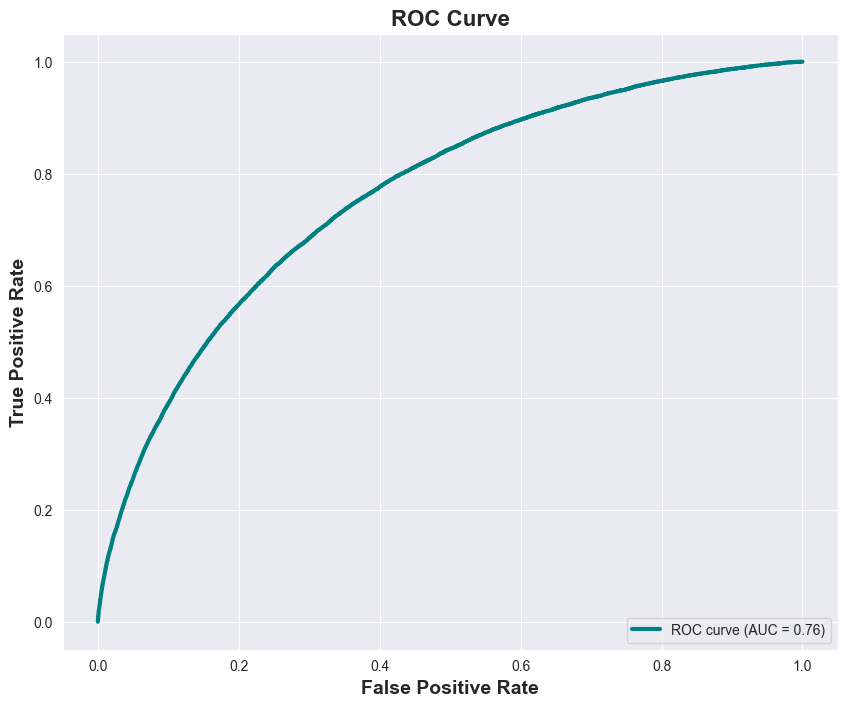

In [182]:
import seaborn as sns
sns.set_style("darkgrid")

fpr, tpr, thresholds = roc_curve(y, oof_preds)
roc_auc = roc_auc_score(y, oof_preds)

plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, color='teal', lw=3, label=f'ROC curve (AUC = {roc_auc:.2f})')

plt.xlabel('False Positive Rate', fontsize=14, weight='bold')
plt.ylabel('True Positive Rate', fontsize=14, weight='bold')
plt.title('ROC Curve', fontsize=16, weight='bold')
plt.legend(loc='lower right')

plt.show()

Feature Importance

In [184]:
print("Feature importance...")
avg_importance = (feature_importance_df[["feature", "importance"]]
                 .groupby("feature")
                 .mean()
                 .sort_values(by="importance", ascending=False))

print(f"\nTop 20 Most Important Features:")
print(avg_importance.head(20))

Feature importance...

Top 20 Most Important Features:
                            importance
feature                               
EXT_SOURCE_3                    1892.0
EXT_SOURCE_1                    1698.0
DAYS_BIRTH                      1507.4
EXT_SOURCE_2                    1484.0
AMT_CREDIT                      1356.4
AMT_ANNUITY                     1284.8
AMT_GOODS_PRICE                 1112.6
DAYS_ID_PUBLISH                 1024.2
DAYS_EMPLOYED                    959.8
DAYS_LAST_PHONE_CHANGE           947.0
DAYS_REGISTRATION                859.6
SK_ID_CURR                       716.6
REGION_POPULATION_RELATIVE       624.0
AMT_INCOME_TOTAL                 596.8
OWN_CAR_AGE                      574.0
AMT_REQ_CREDIT_BUREAU_YEAR       457.8
HOUR_APPR_PROCESS_START          348.4
TOTALAREA_MODE                   309.8
CODE_GENDER_F                    222.6
LANDAREA_MODE                    208.2


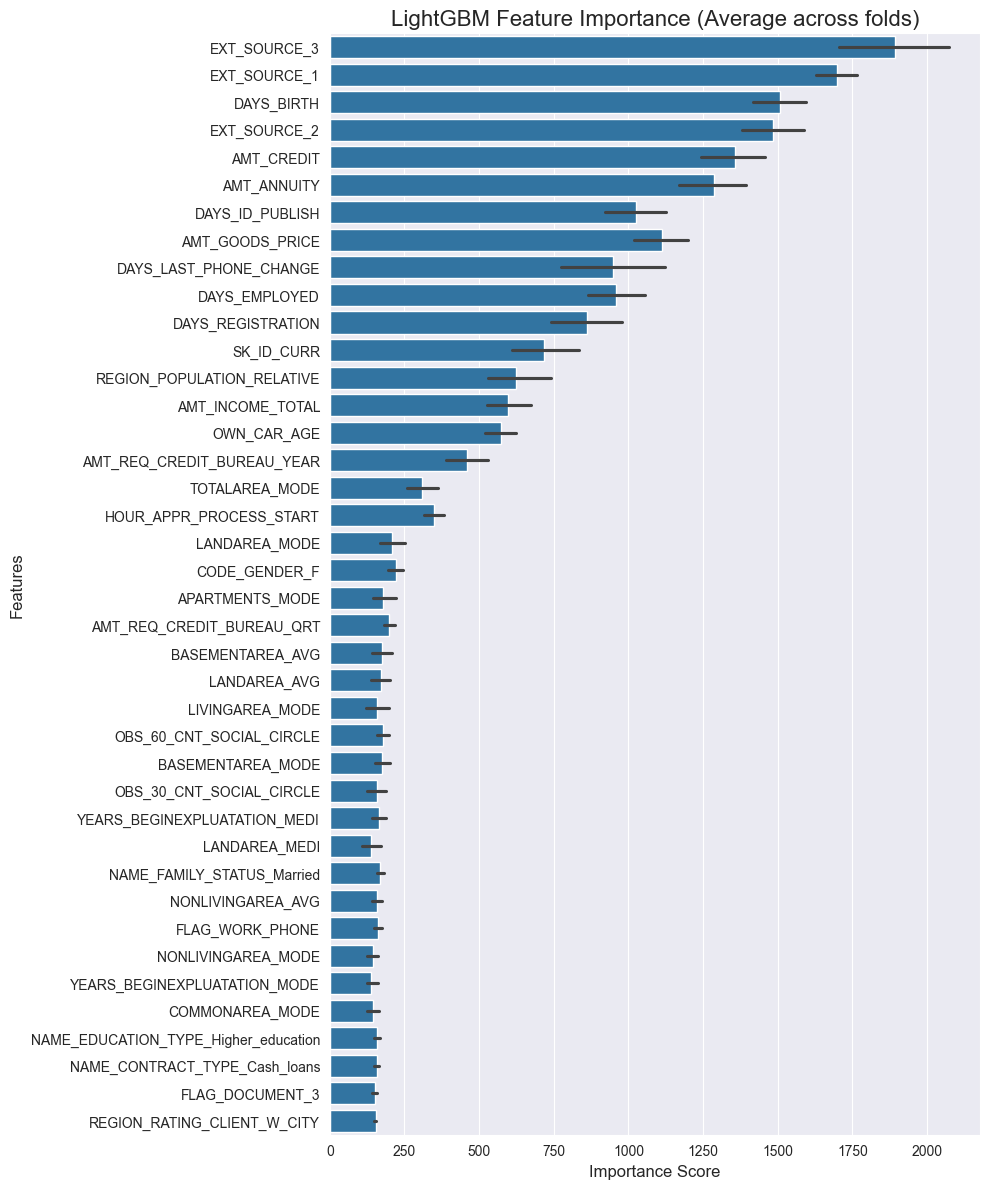

In [185]:
top_features = avg_importance.head(40).index

# Filter data for top features only
best_features = feature_importance_df.loc[feature_importance_df.feature.isin(top_features)]

plt.figure(figsize=(10, 12))
sns.barplot(x="importance", y="feature", 
            data=best_features.sort_values(by="importance", ascending=False))
plt.title('LightGBM Feature Importance (Average across folds)', fontsize=16)
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Features', fontsize=12)

plt.tight_layout()
plt.show()

submission

In [353]:
print("Creating final file...")

final_df = pd.DataFrame({
    "SK_ID_CURR": df_test["SK_ID_CURR"].values,
    "TARGET": test_preds
})

final_file_name = "home_credit_lgbm.csv"

final_df.to_csv(final_file_name, index=False)

print(f"Final file saved as '{final_file_name}'")

Creating final file...
Final file saved as 'home_credit_lgbm.csv'


Try With Feature Engineering

In [189]:
df_train_fet = df_train.copy()
df_test_fet = df_test.copy()

In [205]:
# 1. Credit-to-Income Ratio (CIR)
# Formula: CIR = AMT_CREDIT_x / AMT_INCOME_TOTAL
df_train_fet['INCOME_PER_PERSON'] = df_train_fet['AMT_INCOME_TOTAL'] / (df_train_fet['CNT_FAM_MEMBERS'] + 1)
df_test_fet['INCOME_PER_PERSON'] = df_test_fet['AMT_INCOME_TOTAL'] / (df_test_fet['CNT_FAM_MEMBERS'] + 1)

In [206]:
# 1. Raw data
df_train, df_test

# 2. Feature engineering (HERE ✅)
df_train_fet = df_train.copy()
df_test_fet = df_test.copy()

# add features here

# 3. Separate target
y = df_train_fet['TARGET']
X = df_train_fet.drop(columns=['TARGET'])

# 4. Encoding
X = pd.get_dummies(X)
df_test_fet = pd.get_dummies(df_test_fet)

# 5. Align
X, df_test_fet = X.align(df_test_fet, join='left', axis=1, fill_value=0)

In [207]:
df_train = pd.read_csv('home-credit-default-risk/application_train.csv')
df_test = pd.read_csv('home-credit-default-risk/application_test.csv')

In [208]:
df_train_fet = df_train.copy()
df_test_fet = df_test.copy()

In [215]:
df_train_fet['INCOME_PER_PERSON'] = df_train_fet['AMT_INCOME_TOTAL'] / (df_train_fet['CNT_CHILDREN'] + 1)
df_test_fet['INCOME_PER_PERSON'] = df_test_fet['AMT_INCOME_TOTAL'] / (df_test_fet['CNT_CHILDREN'] + 1)

In [218]:
df_train_fet['CREDIT_TO_INCOME'] = df_train_fet['AMT_CREDIT'] / (df_train_fet['AMT_INCOME_TOTAL'] + 1)
df_test_fet['CREDIT_TO_INCOME'] = df_test_fet['AMT_CREDIT'] / (df_test_fet['AMT_INCOME_TOTAL'] + 1)

In [219]:
df_train_fet['ANNUITY_TO_INCOME'] = df_train_fet['AMT_ANNUITY'] / (df_train_fet['AMT_INCOME_TOTAL'] + 1)
df_test_fet['ANNUITY_TO_INCOME'] = df_test_fet['AMT_ANNUITY'] / (df_test_fet['AMT_INCOME_TOTAL'] + 1)

In [220]:
df_train_fet['CREDIT_TERM'] = df_train_fet['AMT_CREDIT'] / (df_train_fet['AMT_ANNUITY'] + 1)
df_test_fet['CREDIT_TERM'] = df_test_fet['AMT_CREDIT'] / (df_test_fet['AMT_ANNUITY'] + 1)

In [221]:
df_train_fet['INCOME_PER_CHILD'] = df_train_fet['AMT_INCOME_TOTAL'] / (df_train_fet['CNT_CHILDREN'] + 1)
df_test_fet['INCOME_PER_CHILD'] = df_test_fet['AMT_INCOME_TOTAL'] / (df_test_fet['CNT_CHILDREN'] + 1)

In [223]:
y = df_train_fet['TARGET']
X = df_train_fet.drop(columns=['TARGET'])

X = pd.get_dummies(X)
df_test_fet = pd.get_dummies(df_test_fet)

X, df_test_fet = X.align(df_test_fet, join='left', axis=1, fill_value=0)

In [224]:
print(df_train_fet.columns[:10])

Index(['SK_ID_CURR', 'TARGET', 'NAME_CONTRACT_TYPE', 'CODE_GENDER',
       'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL',
       'AMT_CREDIT', 'AMT_ANNUITY'],
      dtype='object')


In [227]:
# Income per child (since CNT_FAM_MEMBERS not available)
df_train_fet['INCOME_PER_CHILD'] = df_train_fet['AMT_INCOME_TOTAL'] / (df_train_fet['CNT_CHILDREN'] + 1)
df_test_fet['INCOME_PER_CHILD'] = df_test_fet['AMT_INCOME_TOTAL'] / (df_test_fet['CNT_CHILDREN'] + 1)

# Credit term
df_train_fet['CREDIT_TERM'] = df_train_fet['AMT_CREDIT'] / (df_train_fet['AMT_ANNUITY'] + 1)
df_test_fet['CREDIT_TERM'] = df_test_fet['AMT_CREDIT'] / (df_test_fet['AMT_ANNUITY'] + 1)

# Credit to income
df_train_fet['CREDIT_TO_INCOME'] = df_train_fet['AMT_CREDIT'] / (df_train_fet['AMT_INCOME_TOTAL'] + 1)
df_test_fet['CREDIT_TO_INCOME'] = df_test_fet['AMT_CREDIT'] / (df_test_fet['AMT_INCOME_TOTAL'] + 1)

In [228]:
print(df_train_fet.columns)

Index(['SK_ID_CURR', 'TARGET', 'NAME_CONTRACT_TYPE', 'CODE_GENDER',
       'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL',
       'AMT_CREDIT', 'AMT_ANNUITY',
       ...
       'AMT_REQ_CREDIT_BUREAU_DAY', 'AMT_REQ_CREDIT_BUREAU_WEEK',
       'AMT_REQ_CREDIT_BUREAU_MON', 'AMT_REQ_CREDIT_BUREAU_QRT',
       'AMT_REQ_CREDIT_BUREAU_YEAR', 'INCOME_PER_PERSON', 'CREDIT_TERM',
       'CREDIT_TO_INCOME', 'ANNUITY_TO_INCOME', 'INCOME_PER_CHILD'],
      dtype='object', length=127)


In [230]:
y = df_train_fet['TARGET']
X = df_train_fet.drop(columns=['TARGET'])

X = pd.get_dummies(X)
df_test_fet = pd.get_dummies(df_test_fet)

X, df_test_fet = X.align(df_test_fet, join='left', axis=1, fill_value=0)

In [289]:
bureau = pd.read_csv('home-credit-default-risk/bureau.csv')

In [297]:
bureau_agg = bureau.groupby('SK_ID_CURR').agg({
    'AMT_CREDIT_SUM_DEBT': ['sum'],
    'AMT_CREDIT_SUM': ['sum'],
    'AMT_CREDIT_SUM_OVERDUE': ['sum']   # 🔥 IMPORTANT
})
bureau_agg.columns = [
    'AMT_CREDIT_SUM_DEBT_sum',
    'AMT_CREDIT_SUM_sum',
    'AMT_CREDIT_SUM_OVERDUE_sum'
]

In [302]:
cols_to_drop = [col for col in df_train_fet.columns if 'AMT_CREDIT_SUM' in col]

print("Dropping:", cols_to_drop)

df_train_fet = df_train_fet.drop(columns=cols_to_drop)
df_test_fet = df_test_fet.drop(columns=cols_to_drop)

Dropping: ['AMT_CREDIT_SUM_DEBT_sum_x', 'AMT_CREDIT_SUM_DEBT_mean', 'AMT_CREDIT_SUM_sum_x', 'AMT_CREDIT_SUM_DEBT_sum_y', 'AMT_CREDIT_SUM_sum_y', 'AMT_CREDIT_SUM_OVERDUE_sum_x', 'AMT_CREDIT_SUM_DEBT_sum', 'AMT_CREDIT_SUM_sum', 'AMT_CREDIT_SUM_OVERDUE_sum_y']


In [303]:
[col for col in df_train_fet.columns if 'AMT_CREDIT_SUM' in col]

[]

In [304]:
bureau_agg = bureau.groupby('SK_ID_CURR').agg({
    'AMT_CREDIT_SUM_DEBT': ['sum'],
    'AMT_CREDIT_SUM': ['sum'],
    'AMT_CREDIT_SUM_OVERDUE': ['sum']
})
bureau_agg.columns = [
    'AMT_CREDIT_SUM_DEBT_sum',
    'AMT_CREDIT_SUM_sum',
    'AMT_CREDIT_SUM_OVERDUE_sum'
]

In [305]:
df_train_fet = df_train_fet.merge(bureau_agg, on='SK_ID_CURR', how='left')

In [306]:
df_test_fet = df_test_fet.merge(bureau_agg, on='SK_ID_CURR', how='left')

In [307]:
print('AMT_CREDIT_SUM_OVERDUE_sum' in df_train_fet.columns)

True


In [308]:
print('Train:', 'AMT_CREDIT_SUM_DEBT_sum' in df_train_fet.columns)
print('Test:', 'AMT_CREDIT_SUM_DEBT_sum' in df_test_fet.columns)

Train: True
Test: True


In [253]:
prev = pd.read_csv('home-credit-default-risk/previous_application.csv')

In [254]:
prev_agg = prev.groupby('SK_ID_CURR').agg({
    'AMT_APPLICATION': ['mean', 'max'],
    'AMT_CREDIT': ['mean']
})

prev_agg.columns = [
    'PREV_AMT_APPLICATION_MEAN',
    'PREV_AMT_APPLICATION_MAX',
    'PREV_AMT_CREDIT_MEAN'
]

In [255]:
df_train_fet = df_train_fet.merge(prev_agg, on='SK_ID_CURR', how='left')
df_test_fet = df_test_fet.merge(prev_agg, on='SK_ID_CURR', how='left')

In [258]:
prev = pd.read_csv('home-credit-default-risk/previous_application.csv')

prev_agg = prev.groupby('SK_ID_CURR').agg({
    'AMT_APPLICATION': 'mean'
})

df_train_fet = df_train_fet.merge(prev_agg, on='SK_ID_CURR', how='left')
df_test_fet = df_test_fet.merge(prev_agg, on='SK_ID_CURR', how='left')

In [261]:
print('AMT_APPLICATION' in df_train_fet.columns)

True


In [264]:
inst = pd.read_csv('home-credit-default-risk/installments_payments.csv')

In [265]:
inst['PAYMENT_DELAY'] = inst['DAYS_ENTRY_PAYMENT'] - inst['DAYS_INSTALMENT']

In [266]:
inst_agg = inst.groupby('SK_ID_CURR').agg({
    'PAYMENT_DELAY': ['max', 'mean'],
    'SK_ID_PREV': 'count'
})

inst_agg.columns = [
    'INST_DELAY_MAX',
    'INST_DELAY_MEAN',
    'INST_CNT'
]

In [267]:
df_train_fet = df_train_fet.merge(inst_agg, on='SK_ID_CURR', how='left')
df_test_fet = df_test_fet.merge(inst_agg, on='SK_ID_CURR', how='left')

In [310]:
inst = pd.read_csv('home-credit-default-risk/installments_payments.csv')

In [311]:
inst['PAY_DIFF'] = inst['AMT_PAYMENT'] - inst['AMT_INSTALMENT']

In [312]:
inst_agg = inst.groupby('SK_ID_CURR').agg({
    'PAY_DIFF': ['min', 'max']
})

inst_agg.columns = [
    'INST_PAY_DIFF_MIN',
    'INST_PAY_DIFF_MAX'
]

In [313]:
df_train_fet = df_train_fet.merge(inst_agg, on='SK_ID_CURR', how='left')
df_test_fet = df_test_fet.merge(inst_agg, on='SK_ID_CURR', how='left')

In [315]:
# 1. Credit-to-Income Ratio (CIR)
# Formula: CIR = AMT_CREDIT_x / AMT_INCOME_TOTAL
df_train_fet['CREDIT_TO_INCOME_RATIO'] = df_train_fet['AMT_CREDIT'] / df_train_fet['AMT_INCOME_TOTAL']
df_test_fet['CREDIT_TO_INCOME_RATIO'] = df_test_fet['AMT_CREDIT'] / df_test_fet['AMT_INCOME_TOTAL']
# 2. Debt-to-Income Ratio (DTI)
# Formula: DTI = (AMT_CREDIT_x + AMT_CREDIT_SUM_DEBT_sum) / AMT_INCOME_TOTAL
df_train_fet['DEBT_TO_INCOME_RATIO'] = (df_train_fet['AMT_CREDIT'] + df_train_fet['AMT_CREDIT_SUM_DEBT_sum']) / df_train_fet['AMT_INCOME_TOTAL']
df_test_fet['DEBT_TO_INCOME_RATIO'] = (df_test_fet['AMT_CREDIT'] + df_test_fet['AMT_CREDIT_SUM_DEBT_sum']) / df_test_fet['AMT_INCOME_TOTAL']
# 3. Loan Amount Overlap
# Formula: Loan Amount Overlap = AMT_CREDIT_x / AMT_APPLICATION
df_train_fet['LOAN_AMOUNT_OVERLAP'] = df_train_fet['AMT_CREDIT'] / df_train_fet['AMT_APPLICATION']
df_test_fet['LOAN_AMOUNT_OVERLAP'] = df_test_fet['AMT_CREDIT'] / df_test_fet['AMT_APPLICATION']
# 4. Credit Utilization
# Formula: Credit Utilization = AMT_CREDIT_SUM_DEBT_sum / AMT_CREDIT_x
df_train_fet['CREDIT_UTILIZATION'] = df_train_fet['AMT_CREDIT_SUM_DEBT_sum'] / df_train_fet['AMT_CREDIT']
df_test_fet['CREDIT_UTILIZATION'] = df_test_fet['AMT_CREDIT_SUM_DEBT_sum'] / df_test_fet['AMT_CREDIT']
# 1. Average Payment Delay
# Formula: INST_DELAY_MAX / INST_CNT (max delay divided by number of installments)
df_train_fet['AVG_PAYMENT_DELAY'] = df_train_fet['INST_DELAY_MAX'] / df_train_fet['INST_CNT']
df_test_fet['AVG_PAYMENT_DELAY'] = df_test_fet['INST_DELAY_MAX'] / df_test_fet['INST_CNT']
# 2. Late Payment Intensity
# Formula: Ratio of late payments to total installments
# We use INST_DELAY_MAX here to reflect the maximum delay (it will indicate intensity of being late).
df_train_fet['LATE_PAYMENT_INTENSITY'] = df_train_fet['INST_DELAY_MAX'] / df_train_fet['INST_CNT']
df_test_fet['LATE_PAYMENT_INTENSITY'] = df_test_fet['INST_DELAY_MAX'] / df_test_fet['INST_CNT']
# 3. Overdue Debt Ratio
# Formula: AMT_CREDIT_SUM_OVERDUE_sum / AMT_CREDIT_SUM_sum
df_train_fet['OVERDUE_DEBT_RATIO'] = df_train_fet['AMT_CREDIT_SUM_OVERDUE_sum'] / df_train_fet['AMT_CREDIT_SUM_sum']
df_test_fet['OVERDUE_DEBT_RATIO'] = df_test_fet['AMT_CREDIT_SUM_OVERDUE_sum'] / df_test_fet['AMT_CREDIT_SUM_sum']
# 4. Instalment Payment Consistency
# Formula: Standard Deviation of payment differences (INST_PAY_DIFF_MIN, INST_PAY_DIFF_MAX)
df_train_fet['INST_PAYMENT_CONSISTENCY'] = df_train_fet[['INST_PAY_DIFF_MIN', 'INST_PAY_DIFF_MAX']].std(axis=1)
df_test_fet['INST_PAYMENT_CONSISTENCY'] = df_test_fet[['INST_PAY_DIFF_MIN', 'INST_PAY_DIFF_MAX']].std(axis=1)

In [316]:
df_train_fet

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,INCOME_PER_PERSON,CREDIT_TERM,CREDIT_TO_INCOME,ANNUITY_TO_INCOME,INCOME_PER_CHILD,CREDIT_TO_INCOME_RATIO,DEBT_TO_INCOME_RATIO,AMT_APPLICATION_mean,AMT_APPLICATION_sum,PREV_AMT_CREDIT_mean,AMT_APPLICATION_x,AMT_APPLICATION_y,PREV_AMT_APPLICATION_MEAN,PREV_AMT_APPLICATION_MAX,PREV_AMT_CREDIT_MEAN,AMT_APPLICATION,LOAN_AMOUNT_OVERLAP,CREDIT_UTILIZATION,INST_DELAY_MAX,INST_DELAY_MEAN,INST_CNT,AVG_PAYMENT_DELAY,LATE_PAYMENT_INTENSITY,AMT_CREDIT_SUM_DEBT_sum,AMT_CREDIT_SUM_sum,AMT_CREDIT_SUM_OVERDUE_sum,OVERDUE_DEBT_RATIO,INST_PAY_DIFF_MIN,INST_PAY_DIFF_MAX,INST_PAYMENT_CONSISTENCY
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,351000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.018801,-9461,-637,-3648.0,-2120,NaN,1,1,0,1,1,0,Laborers,1.0,2,2,WEDNESDAY,10,0,0,0,0,0,0,Business Entity Type 3,0.083037,0.262949,0.139376,0.0247,0.0369,0.9722,0.6192,0.0143,0.00,0.0690,0.0833,0.1250,0.0369,0.0202,0.0190,0.0000,0.0000,0.0252,0.0383,0.9722,0.6341,0.0144,0.0000,0.0690,0.0833,0.1250,0.0377,0.0220,0.0198,0.0,0.0000,0.0250,0.0369,0.9722,0.6243,0.0144,0.00,0.0690,0.0833,0.1250,0.0375,0.0205,0.0193,0.0000,0.0000,reg oper account,block of flats,0.0149,"Stone, brick",No,2.0,2.0,2.0,2.0,-1134.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0,202500.0,16.460438,2.007879,0.121977,202500.0,2.007889,3.221622,179055.000,179055.00,179055.00,179055.000,179055.000,179055.000,179055.0,179055.00,179055.000,2.270797,0.604482,-12.0,-20.421053,19.0,-0.631579,-0.631579,245781.00,865055.565,0.0,0.0,0.000,0.000,0.000000
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,1129500.0,Family,State servant,Higher education,Married,House / apartment,0.003541,-16765,-1188,-1186.0,-291,NaN,1,1,0,1,1,0,Core staff,2.0,1,1,MONDAY,11,0,0,0,0

In [320]:
y = df_train_fet['TARGET']
X = df_train_fet.drop(columns=['TARGET'])

# One-hot encoding
X = pd.get_dummies(X)
df_test_fet = pd.get_dummies(df_test_fet)

# Align train & test
X, df_test_fet = X.align(df_test_fet, join='left', axis=1, fill_value=0)

In [326]:
# one-hot-encoding

df_train_fet = pd.get_dummies(df_train_fet)
df_test_fet = pd.get_dummies(df_test_fet)

print('Training Features shape: ', df_train_fet.shape)
print('Testing Features shape: ', df_test_fet.shape)

Training Features shape:  (307511, 273)
Testing Features shape:  (48744, 272)


In [327]:
y = df_train_fet['TARGET']
X = df_train_fet.drop(columns=['TARGET'])
X = pd.get_dummies(X)
df_test_fet = pd.get_dummies(df_test_fet)
X, df_test_fet = X.align(df_test_fet, join='left', axis=1, fill_value=0)
X_test = df_test_fet

In [328]:
features = [col for col in df_train_fet.columns if col not in [TARGET, ID]]
X = df_train_fet[features]
y = df_train_fet[TARGET]
X_test  = df_test_fet[features]

In [329]:
X.columns = X.columns.str.replace(r'[^a-zA-Z0-9_]', '_', regex=True)
X_test.columns = X_test.columns.str.replace(r'[^a-zA-Z0-9_]', '_', regex=True)

In [330]:
print(f"Training data shape: {X.shape}")
print(f"Test data shape: {X_test.shape}")
print(f"Number of features: {len(features)}")
print(f"Target distribution: {y.value_counts().sort_index()}")

Training data shape: (307511, 271)
Test data shape: (48744, 271)
Number of features: 271
Target distribution: TARGET
0    282686
1     24825
Name: count, dtype: int64


In [331]:
num_folds = 10

In [332]:
if stratified:
    folds = StratifiedKFold(n_splits=num_folds, shuffle=True, random_state=1001)
    print(f"Using Stratified {num_folds}-fold cross-validation")
else:
    folds = KFold(n_splits=num_folds, shuffle=True, random_state=1001)
    print(f"Using Regular {num_folds}-fold cross-validation")

Using Stratified 10-fold cross-validation


In [333]:
# Initialize result containers
oof_preds = np.zeros(X.shape[0])  # Out-of-fold predictions
test_preds = np.zeros(X_test.shape[0])  # Test set predictions
feature_importance_df = pd.DataFrame()

print("Cross-validation setup completed")

print("Starting cross-validation training...")
cv_start_time = time.time()

for n_fold, (train_idx, valid_idx) in enumerate(folds.split(X, y)):
    print(f"\n=== Fold {n_fold + 1}/{num_folds} ===")
    fold_start_time = time.time()
    
    # Split data for current fold
    X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
    y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]
    
    print(f"Train shape: {X_train.shape}, Valid shape: {X_valid.shape}")
    print(f"Train target distribution: {y_train.value_counts().sort_index().to_dict()}")
    print(f"Valid target distribution: {y_valid.value_counts().sort_index().to_dict()}")

    # Initialize LightGBM parameters
    clf = LGBMClassifier(
        n_jobs=4,                     # Use 4 CPU threads for parallel processing
        n_estimators=10000,           # Maximum number of boosting rounds
        learning_rate=0.02,           # Learning rate (small for better performance)
        num_leaves=34,                # Number of leaves in each tree
        colsample_bytree=0.9497036,   # Fraction of features used per tree
        subsample=0.8715623,          # Fraction of samples used per tree
        max_depth=8,                  # Maximum tree depth
        reg_alpha=0.041545473,        # L1 regularization
        reg_lambda=0.0735294,         # L2 regularization
        min_split_gain=0.0222415,     # Minimum gain to make split
        min_child_weight=39.3259775,  # Minimum sum of instance weight in child
        verbosity=-1,                 # Updated from 'verbose' - controls LightGBM's own verbosity
        random_state=1001,            # For reproducibility
        force_col_wise=True           # Forces the algorithm to work with column-wise data for better performance
    )

    # Setup callbacks for training 
    callbacks = [
        log_evaluation(period=200),   
        early_stopping(stopping_rounds=200)  
    ]

    # Train model with callbacks
    clf.fit(X_train, y_train, 
            eval_set=[(X_train, y_train), (X_valid, y_valid)], 
            eval_metric='auc',           # Use AUC as evaluation metric, as asked in the competition
            callbacks=callbacks)         # Use callbacks instead of verbose and early_stopping_rounds

    # Generate out-of-fold predictions
    oof_preds[valid_idx] = clf.predict_proba(X_valid)[:, 1]
    
    # Generate test predictions and accumulate
    test_preds += clf.predict_proba(X_test)[:, 1] / folds.n_splits

    # Store feature importance for this fold
    fold_importance_df = pd.DataFrame()
    fold_importance_df["feature"] = features
    fold_importance_df["importance"] = clf.feature_importances_
    fold_importance_df["fold"] = n_fold + 1
    feature_importance_df = pd.concat([feature_importance_df, fold_importance_df], axis=0)
    
    # Calculate and print fold performance
    fold_auc = roc_auc_score(y_valid, oof_preds[valid_idx])
    print(f'Fold {n_fold + 1:2d} AUC: {fold_auc:.6f}')
    print(f'Best iteration: {clf.best_iteration_}')
    print(f'Fold {n_fold + 1} completed in {time.time() - fold_start_time:.0f}s')
    
    # Clean up memory
    del clf, X_train, X_valid, y_train, y_valid
    gc.collect()

print(f"\nCross-validation completed in {time.time() - cv_start_time:.0f}s")

Cross-validation setup completed
Starting cross-validation training...

=== Fold 1/10 ===
Train shape: (276759, 271), Valid shape: (30752, 271)
Train target distribution: {0: 254417, 1: 22342}
Valid target distribution: {0: 28269, 1: 2483}
Training until validation scores don't improve for 200 rounds
[200]	training's auc: 0.781955	training's binary_logloss: 0.240063	valid_1's auc: 0.758332	valid_1's binary_logloss: 0.24675
[400]	training's auc: 0.801439	training's binary_logloss: 0.232701	valid_1's auc: 0.768661	valid_1's binary_logloss: 0.243438
[600]	training's auc: 0.813164	training's binary_logloss: 0.228405	valid_1's auc: 0.771419	valid_1's binary_logloss: 0.242475
[800]	training's auc: 0.823423	training's binary_logloss: 0.224691	valid_1's auc: 0.77318	valid_1's binary_logloss: 0.241901
[1000]	training's auc: 0.832819	training's binary_logloss: 0.221201	valid_1's auc: 0.774514	valid_1's binary_logloss: 0.241479
[1200]	training's auc: 0.841521	training's binary_logloss: 0.217928	v

In [334]:
overall_auc = roc_auc_score(y, oof_preds)
print(f'\n{"="*50}')
print(f'FINAL RESULTS')
print(f'{"="*50}')
print(f'Overall AUC Score: {overall_auc:.6f}')

# Calculate fold-wise AUC scores for detailed analysis
fold_aucs = []
for n_fold, (train_idx, valid_idx) in enumerate(folds.split(X, y)):
    fold_auc = roc_auc_score(y.iloc[valid_idx], oof_preds[valid_idx])
    fold_aucs.append(fold_auc)
    print(f'Fold {n_fold + 1:2d} AUC: {fold_auc:.6f}')

print(f'\nAUC Statistics:')
print(f'Mean: {np.mean(fold_aucs):.6f}')
print(f'Std:  {np.std(fold_aucs):.6f}')
print(f'Min:  {np.min(fold_aucs):.6f}')
print(f'Max:  {np.max(fold_aucs):.6f}')


FINAL RESULTS
Overall AUC Score: 0.778860
Fold  1 AUC: 0.775591
Fold  2 AUC: 0.774864
Fold  3 AUC: 0.776220
Fold  4 AUC: 0.778539
Fold  5 AUC: 0.774482
Fold  6 AUC: 0.781513
Fold  7 AUC: 0.783033
Fold  8 AUC: 0.783224
Fold  9 AUC: 0.780573
Fold 10 AUC: 0.780733

AUC Statistics:
Mean: 0.778877
Std:  0.003207
Min:  0.774482
Max:  0.783224


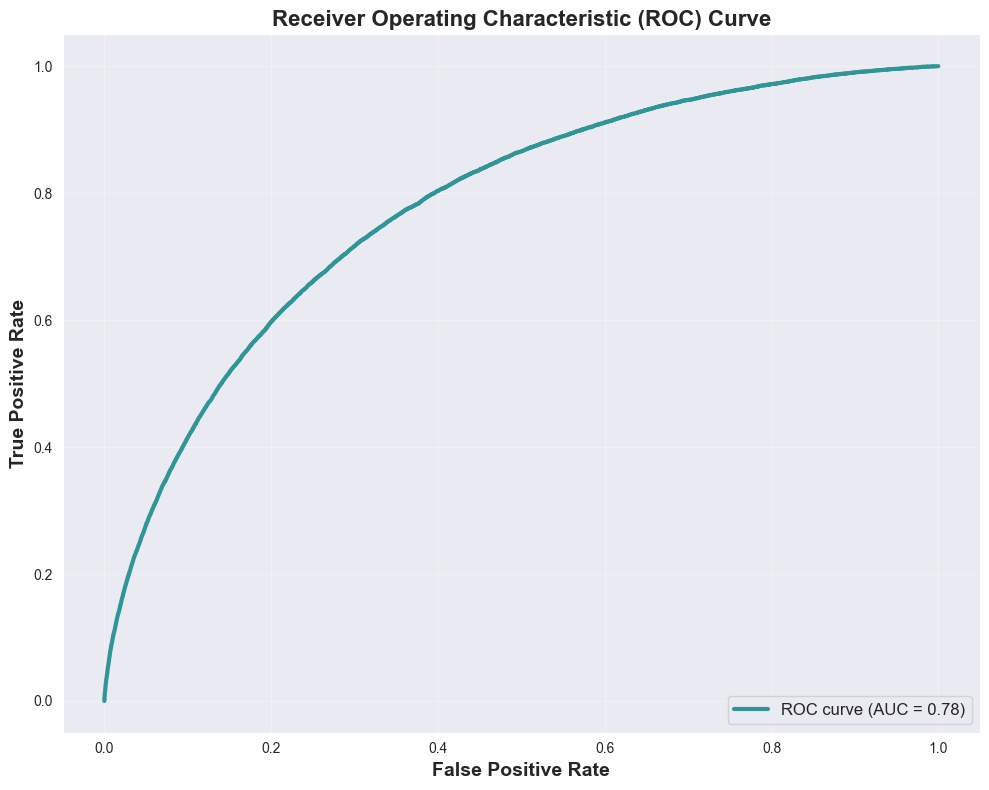

In [340]:
# Plot ROC curve for the final model (using all predictions)
import seaborn as sns
sns.set_style('darkgrid')
fpr, tpr, thresholds = roc_curve(y, oof_preds)
roc_auc = roc_auc_score(y, oof_preds)

# Plot the ROC curve
plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, color='teal', lw=3, label=f'ROC curve (AUC = {roc_auc:.2f})', alpha=0.8)

plt.xlabel('False Positive Rate', fontsize=14, weight='bold')
plt.ylabel('True Positive Rate', fontsize=14, weight='bold')
plt.title('Receiver Operating Characteristic (ROC) Curve', fontsize=16, weight='bold')
plt.legend(loc='lower right', fontsize=12)

plt.grid(True, linestyle='-', alpha=0.3)

plt.tight_layout()
plt.show()

In [352]:
print("Creating final file...")

final_file_df = pd.DataFrame({
    "SK_ID_CURR": df_test["SK_ID_CURR"].values,
    "TARGET": test_preds
})

final_file = "home_credit_final.csv"

final_file_df.to_csv(final_file, index=False)

print(f"Final file saved as '{final_file}'")

Creating final file...
Final file saved as 'home_credit_final.csv'


In [358]:
from sklearn.model_selection import StratifiedKFold
from lightgbm import LGBMClassifier
import joblib

folds = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = []

for n_fold, (train_idx, valid_idx) in enumerate(folds.split(X, y)):

    X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
    y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]

    model = LGBMClassifier(
        n_estimators=1000,
        learning_rate=0.05,
        random_state=42
    )

    model.fit(X_train, y_train)

    models.append(model)

# ✅ Save all models
joblib.dump(models, "models.pkl")

['models.pkl']

In [360]:
joblib.dump(X.columns.tolist(), "features.pkl")

['features.pkl']

In [363]:
def full_pipeline(df):
    
    # feature engineering
    df['CREDIT_INCOME_RATIO'] = df['AMT_CREDIT'] / df['AMT_INCOME_TOTAL']
    
    # preprocessing
    df = df.fillna(0)
    
    return df

In [364]:
pipeline = {
    "model": model,
    "features": X.columns.tolist()
}

joblib.dump(pipeline, "pipeline.pkl")

['pipeline.pkl']

In [375]:
pipeline = joblib.load("pipeline.pkl")

model = pipeline["model"]
features = pipeline["features"]

# take sample
new_data = X.iloc[[74]].copy()

# process
new_data = full_pipeline(new_data)
new_data = new_data[features]

# predict
pred = model.predict_proba(new_data)[:, 1]

print("Default Probability:", pred)

Default Probability: [0.35739508]


In [377]:
print("AUC:", roc_auc_score(y, oof_preds))

AUC: 0.7788597278506552


In [378]:
import pandas as pd

feat_imp = pd.DataFrame({
    'feature': features,
    'importance': model.feature_importances_
}).sort_values(by='importance', ascending=False)

print(feat_imp.head(10))

                feature  importance
32         EXT_SOURCE_3        1201
108         CREDIT_TERM        1135
31         EXT_SOURCE_2        1051
30         EXT_SOURCE_1        1024
131  AMT_CREDIT_SUM_sum         913
9            DAYS_BIRTH         907
12      DAYS_ID_PUBLISH         849
126     INST_DELAY_MEAN         826
11    DAYS_REGISTRATION         750
127            INST_CNT         731


In [380]:
!pip install shap

   ---------------------------------------- 0.0/555.9 kB ? eta -:--:--
   ---------------------------------------- 555.9/555.9 kB 2.6 MB/s eta 0:00:00
   ---------------------------------------- 0.0/38.1 MB ? eta -:--:--
    --------------------------------------- 0.5/38.1 MB 3.1 MB/s eta 0:00:13
   - -------------------------------------- 1.3/38.1 MB 3.3 MB/s eta 0:00:12
   -- ------------------------------------- 2.1/38.1 MB 3.5 MB/s eta 0:00:11
   --- ------------------------------------ 2.9/38.1 MB 3.6 MB/s eta 0:00:10
   --- ------------------------------------ 3.7/38.1 MB 3.6 MB/s eta 0:00:10
   ---- ----------------------------------- 4.5/38.1 MB 3.7 MB/s eta 0:00:10
   ----- ---------------------------------- 5.2/38.1 MB 3.7 MB/s eta 0:00:09
   ------ --------------------------------- 6.0/38.1 MB 3.7 MB/s eta 0:00:09
   ------- -------------------------------- 6.8/38.1 MB 3.7 MB/s eta 0:00:09
   ------- -------------------------------- 7.6/38.1 MB 3.7 MB/s eta 0:00:09
   ------


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


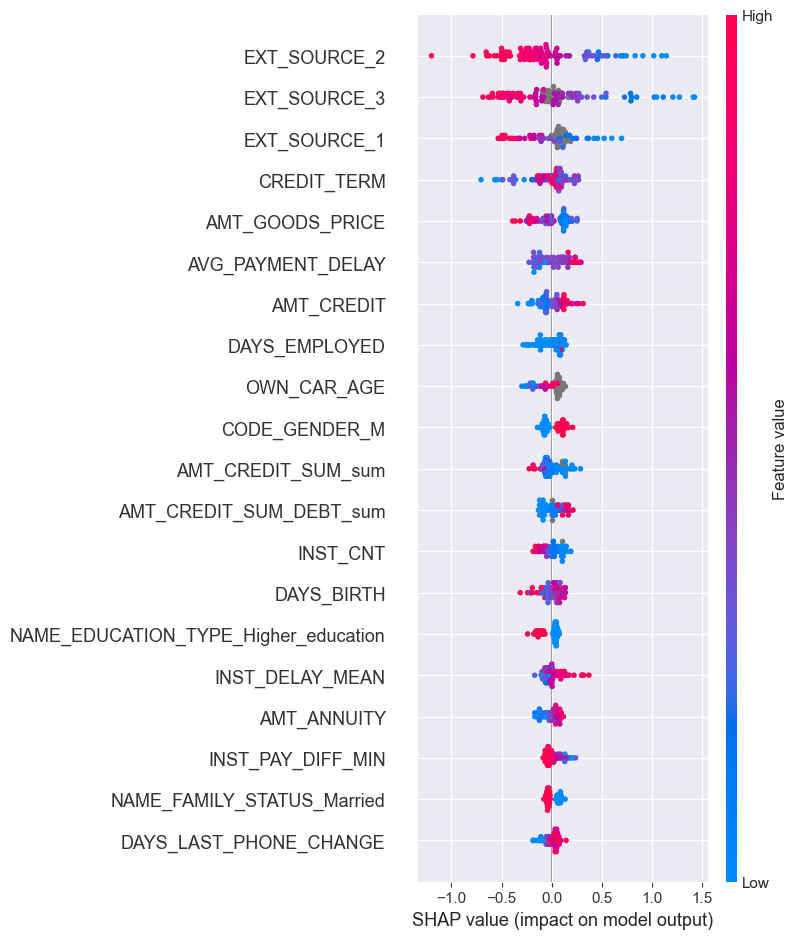

In [381]:
import shap

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X.iloc[:100])

shap.summary_plot(shap_values, X.iloc[:100])

In [382]:
plt.savefig("shap_summary.png")

<Figure size 640x480 with 0 Axes>

In [383]:
joblib.dump(X, "processed_data.pkl")

['processed_data.pkl']

In [391]:
import joblib
import pandas as pd

pipeline = joblib.load("pipeline.pkl")

if isinstance(pipeline, dict):
    model = pipeline["model"]
    features = pipeline["features"]
else:
    raise ValueError("Invalid pipeline format")


def predict(data):
    if not isinstance(data, pd.DataFrame):
        raise ValueError("Input must be a pandas DataFrame")

    # Align features
    data = data.reindex(columns=features, fill_value=0)

    pred = model.predict_proba(data)[:, 1]
    return pred.tolist()


if __name__ == "__main__":
    sample = pd.read_csv("home_credit_final.csv").iloc[:1]
    
    prediction = predict(sample)
    print("Default Probability:", prediction[0])

Default Probability: 0.8595578745924797


In [392]:
pipeline = joblib.load("pipeline.pkl")
print(type(pipeline))

<class 'dict'>


In [393]:
import joblib
import pandas as pd

# Load pipeline
pipeline = joblib.load("pipeline.pkl")

model = pipeline["model"]
features = pipeline["features"]

def predict(data):
    # Ensure DataFrame
    if not isinstance(data, pd.DataFrame):
        raise ValueError("Input must be DataFrame")

    # Align features
    data = data.reindex(columns=features, fill_value=0)

    # Predict
    prob = model.predict_proba(data)[:, 1]
    return prob


# 🔥 TEST 1: Using processed dataset
sample = pd.read_csv("home_credit_final.csv").iloc[:1]

print("Notebook Prediction:", predict(sample)[0])

Notebook Prediction: 0.8595578745924797


In [395]:
test_inputs = [
    {"AMT_INCOME_TOTAL": 100000, "AMT_CREDIT": 500000},
    {"AMT_INCOME_TOTAL": 50000, "AMT_CREDIT": 100000},
    {"AMT_INCOME_TOTAL": 300000, "AMT_CREDIT": 1000000}
]

for inp in test_inputs:
    df = pd.DataFrame([inp])
    print(inp, "→", predict(df)[0])

{'AMT_INCOME_TOTAL': 100000, 'AMT_CREDIT': 500000} → 0.8538784406162745
{'AMT_INCOME_TOTAL': 50000, 'AMT_CREDIT': 100000} → 0.8664106696426168
{'AMT_INCOME_TOTAL': 300000, 'AMT_CREDIT': 1000000} → 0.8935165884481303


In [401]:
import pandas as pd
import joblib

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from lightgbm import LGBMClassifier

# Load correct dataset
df = pd.read_csv("home-credit-default-risk/application_train.csv")

print("TARGET present:", "TARGET" in df.columns)

# Split
X = df.drop("TARGET", axis=1)
y = df["TARGET"]

# Columns
num_cols = X.select_dtypes(include=["int64", "float64"]).columns
cat_cols = X.select_dtypes(include=["object"]).columns

print("Num cols:", len(num_cols))
print("Cat cols:", len(cat_cols))

# Pipelines
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", num_pipeline, num_cols),
    ("cat", cat_pipeline, cat_cols)
])

# Final pipeline
pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LGBMClassifier(
        n_estimators=300,
        learning_rate=0.05,
        random_state=42
    ))
])

# Train
pipeline.fit(X, y)

# Save
joblib.dump(pipeline, "pipeline_full.pkl")

print("✅ FULL PIPELINE TRAINED & SAVED")

TARGET present: True
Num cols: 105
Cat cols: 16
✅ FULL PIPELINE TRAINED & SAVED


In [404]:
pipeline = joblib.load("pipeline_full.pkl")

print(type(pipeline))
print(pipeline)

<class 'sklearn.pipeline.Pipeline'>
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  Index(['SK_ID_CURR', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'AMT_CREDIT',
       'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'REGION_POPULATION_RELATIVE',
       'DAYS_BIRTH', 'DAYS_EMPLOYED', 'DAYS_REGISTRATION',
       ...
       'FLAG_DOCUMENT_18', 'FLAG_DOCUMENT_19...
                                                  Index(['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY',
       'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE',
       'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE',
       'WEEKDAY_APPR_PROCESS_START', 'ORGANIZATION_TYPE', 'FONDKAPREMONT_MODE',
       'HOUSETYPE_MODE', 'WALLSMATE

In [412]:
print(type(pipeline))
print(type(model))

<class 'sklearn.pipeline.Pipeline'>
<class 'lightgbm.sklearn.LGBMClassifier'>
